# ARIMA

In [2]:
## 1. Cài đặt và import thư viện

# Cài đặt `pmdarima` nếu môi trường hiện tại chưa có thư viện này.
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 27.7 MB/s eta 0:00:00


In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

In [4]:
# Config cho việc visualization

GREEN      = "#344f1e"
BLUE       = "#2f6f9f"
RED        = "#b5432f"
GRAY       = "#5f6b5d"
LIGHT_GREEN = "#eef4e8"
DARK = "#111827"
ORANGE = "#F59E0B"


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [5]:
## 2. Chuẩn bị và chia dữ liệu

train = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-daily-xgb/PM25_2026_Q1_train_daily.csv")
test = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-daily-xgb/PM25_2026_Q1_test_daily.csv")

train['Local Time'] = pd.to_datetime(train['Local Time'])
test['Local Time'] = pd.to_datetime(test['Local Time'])

# Chuyển DL về dạng series
train = pd.Series(
    train["PM25"].values,
    index=train["Local Time"],
    name="PM25" 
)

test = pd.Series(
    test["PM25"].values,
    index=test["Local Time"],
    name="PM25" 
)

# Chuyển về ngày
train = train.asfreq('D')
test = test.asfreq('D')

print(train.head().to_string())
print(f"Train: {train.index[0]} đến {train.index[-1]} ({len(train)} quan sát)")
print(f"Test:  {test.index[0]} đến {test.index[-1]} ({len(test)} quan sát)")

Local Time
2026-01-01    26.275000
2026-01-02    25.283333
2026-01-03    45.412500
2026-01-04    64.450000
2026-01-05    30.883333
Freq: D
Train: 2026-01-01 00:00:00 đến 2026-03-24 00:00:00 (83 quan sát)
Test:  2026-03-25 00:00:00 đến 2026-03-31 00:00:00 (7 quan sát)


## 3. Trực quan hóa tập huấn luyện

Trước khi mô hình hóa, ta quan sát chuỗi trên tập huấn luyện để nhận diện sơ bộ chu kỳ, biên độ dao động và các giai đoạn biến động mạnh.

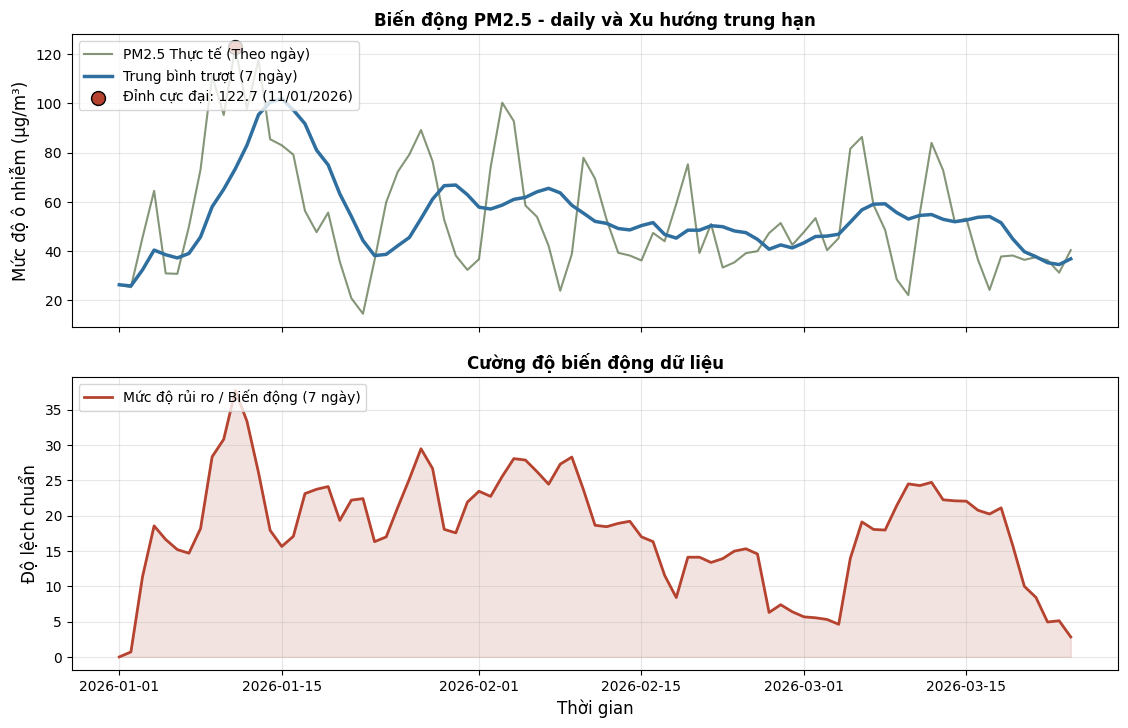

In [6]:
# ==========================================
# 1. TÍNH TOÁN BẰNG PANDAS (Nhanh và chính xác hơn Numpy thuần)
# ==========================================

# Thiết lập cửa sổ trượt: 7 đơn vị (Tương đương 7 ngày vì dữ liệu đang là Daily)
window = 7 

# Dùng hàm .rolling() siêu cấp của Pandas
# min_periods=1 giúp tính toán ngay từ ngày đầu tiên thay vì bị NaN ở 6 ngày đầu
rolling_mean = train.rolling(window=window, min_periods=1).mean()
rolling_std  = train.rolling(window=window, min_periods=1).std()

# Tìm giá trị và thời điểm đạt đỉnh ô nhiễm lớn nhất
peak_val = train.max()
peak_time = train.idxmax() # idxmax() lấy ra index (ngày) có giá trị max
peak_time_str = peak_time.strftime('%d/%m/%Y') # Format lại ngày cho đẹp

# ==========================================
# 2. VẼ ĐỒ THỊ
# ==========================================

fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.5), sharex=True)

# --- Subplot 1: Giá trị PM2.5 và Trung bình trượt ---
ax = axes[0]
ax.plot(train.index, train.values, color=GREEN, linewidth=1.5, alpha=0.6, label="PM2.5 Thực tế (Theo ngày)")
ax.plot(train.index, rolling_mean, color=BLUE, linewidth=2.5, label=f"Trung bình trượt ({window} ngày)")

# Đánh dấu đỉnh cực đại
ax.scatter([peak_time], [peak_val], s=100, color=RED, zorder=5, edgecolors='black',
           label=f"Đỉnh cực đại: {peak_val:.1f} ({peak_time_str})")

ax.set_title("Biến động PM2.5 - daily và Xu hướng trung hạn", fontsize=12, fontweight='bold')
ax.set_ylabel("Mức độ ô nhiễm (µg/m³)")
ax.legend(loc="upper left", ncol=1, frameon=True)
ax.grid(alpha=0.3)

# --- Subplot 2: Độ lệch chuẩn trượt ---
ax = axes[1]
# Xử lý trường hợp ngày đầu tiên std bị NaN (do không đủ 2 điểm để tính độ lệch)
rolling_std_clean = rolling_std.fillna(0) 

ax.plot(train.index, rolling_std_clean, color=RED, linewidth=2.0, label=f"Mức độ rủi ro / Biến động ({window} ngày)")
ax.fill_between(train.index, 0, rolling_std_clean, color=RED, alpha=0.15)

ax.set_title("Cường độ biến động dữ liệu", fontsize=12, fontweight='bold')
ax.set_xlabel("Thời gian")
ax.set_ylabel("Độ lệch chuẩn")
ax.legend(loc="upper left", frameon=True)
ax.grid(alpha=0.3)

fig.tight_layout(pad=1.5)
plt.show()

## 4. Kiểm tra tính dừng và chọn \(d\)

Ta dùng kiểm định Augmented Dickey–Fuller (ADF) cho chuỗi gốc và chuỗi sau sai phân bậc một.

In [7]:
raw_adf_stat, raw_p_value, *_ = adfuller(train)

diff_train = train.diff().dropna()
diff_adf_stat, diff_p_value, *_ = adfuller(diff_train)

log_train = np.log(train.replace(0, np.nan)).dropna()
log_adf_stat, log_p_value, *_ = adfuller(log_train)

diff_log_train = log_train.diff().dropna()
diff_log_adf_stat, diff_log_p_value, *_ = adfuller(diff_log_train)

print(f"ADF statistic train series: {raw_adf_stat:.4f}")
print(f"ADF p-value train series: {raw_p_value:.4f}")
print(f"ADF statistic first difference: {diff_adf_stat:.4f}")
print(f"ADF p-value first difference: {diff_p_value:.4e}")
print(f"ADF statistic log-transformed: {log_adf_stat:.4f}")
print(f"ADF p-value log-transformed: {log_p_value:.4e}")
print(f"ADF statistic log-differenced: {diff_log_adf_stat:.4f}")
print(f"ADF p-value log-differenced: {diff_log_p_value:.4e}")

ADF statistic train series: -2.8266
ADF p-value train series: 0.0546
ADF statistic first difference: -6.3518
ADF p-value first difference: 2.6005e-08
ADF statistic log-transformed: -5.5151
ADF p-value log-transformed: 1.9331e-06
ADF statistic log-differenced: -6.4000
ADF p-value log-differenced: 2.0070e-08


Nếu chuỗi gốc chưa dừng nhưng chuỗi sai phân bậc một dừng, ta chọn \(d=1\).

Nhưng mà ta lại thấy chuỗi log dừng :< lấy chuỗi log

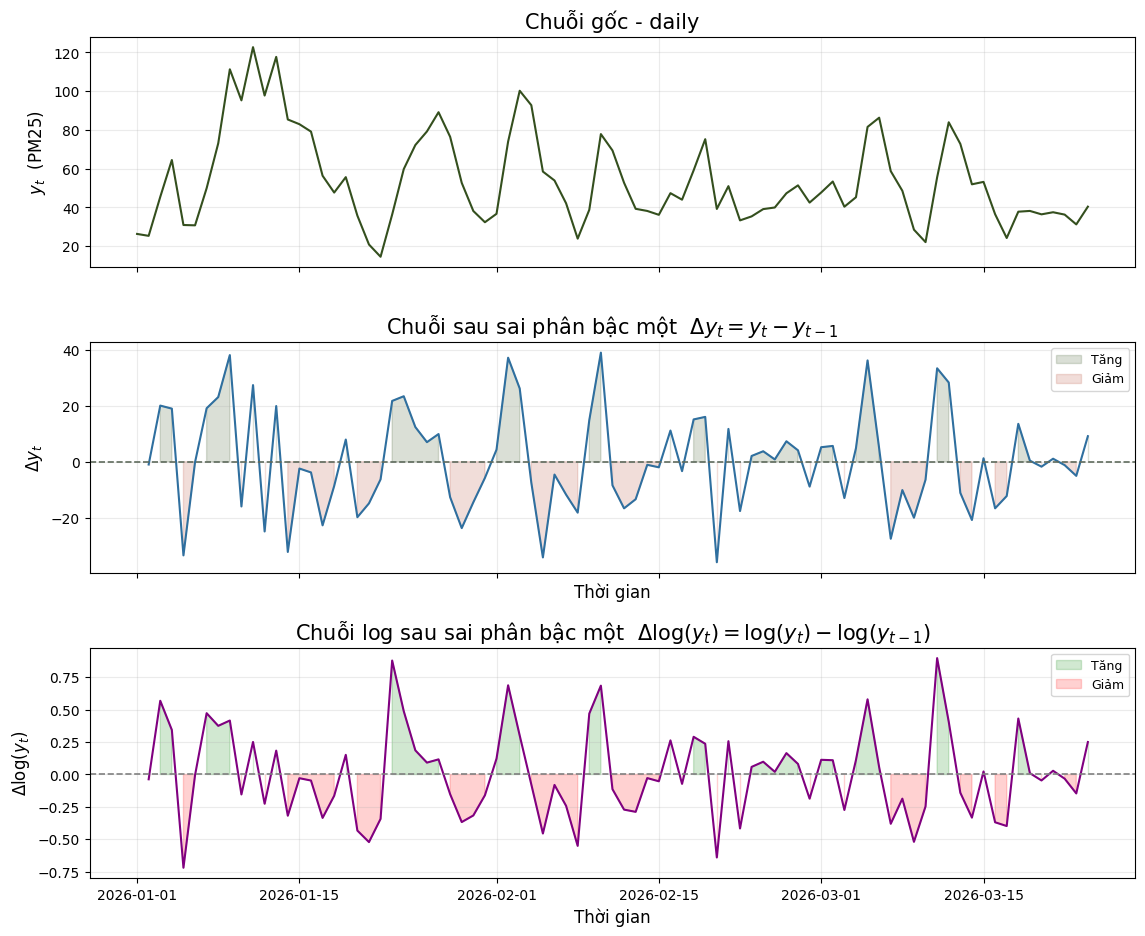

In [8]:
t = train.index.to_numpy()
y = train.to_numpy()
dy = np.diff(y)

y_log = np.log1p(np.asarray(y, dtype=float)) 
dy_log = np.diff(y_log)

t_diff = t[1:]
fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.5), sharex=True)

# Ensure arrays align and contain no NaN/inf (needed for fill_between)
t_np = np.asarray(t)
y_np = np.asarray(y, dtype=float)
td_np = np.asarray(t_diff)
dy_np = np.asarray(dy, dtype=float)
dy_log_np = np.asarray(dy_log, dtype=float) # Biến mới cho chuỗi log

n = min(len(td_np), len(dy_np))
td_np = td_np[:n]
dy_np = dy_np[:n]
dy_log_np = dy_log_np[:n]

# Điều kiện hợp lệ cho fill_between không bị lỗi
valid = np.isfinite(td_np) & np.isfinite(dy_np)
valid_log = np.isfinite(td_np) & np.isfinite(dy_log_np)

a0 = axes[0]
a0.plot(t_np, y_np, color=GREEN, linewidth=1.5)
a0.set_title("Chuỗi gốc - daily")
a0.set_ylabel(r"$y_t$  (PM25)")
a0.grid(alpha=0.25)

a1 = axes[1]
a1.plot(td_np[valid], dy_np[valid], color=BLUE, linewidth=1.5)
a1.axhline(0, color=GRAY, linewidth=1.2, linestyle="--")
a1.fill_between(td_np[valid], 0, dy_np[valid], where=(dy_np[valid] >= 0), color=GREEN, alpha=0.18, label="Tăng")
a1.fill_between(td_np[valid], 0, dy_np[valid], where=(dy_np[valid] <  0), color=RED,   alpha=0.18, label="Giảm")
a1.set_title(r"Chuỗi sau sai phân bậc một  $\Delta y_t = y_t - y_{t-1}$")
a1.set_ylabel(r"$\Delta y_t$")
a1.set_xlabel("Thời gian")
a1.legend(loc="upper right", frameon=True, fontsize=9)
a1.grid(alpha=0.25)

a2 = axes[2] # Sử dụng axes[2] cho đồ thị thứ 3
a2.plot(td_np[valid_log], dy_log_np[valid_log], color='purple', linewidth=1.5) # Đổi màu cho dễ phân biệt
a2.axhline(0, color='gray', linewidth=1.2, linestyle="--")
a2.fill_between(td_np[valid_log], 0, dy_log_np[valid_log], where=(dy_log_np[valid_log] >= 0), color='green', alpha=0.18, label="Tăng")
a2.fill_between(td_np[valid_log], 0, dy_log_np[valid_log], where=(dy_log_np[valid_log] <  0), color='red',   alpha=0.18, label="Giảm")
a2.set_title(r"Chuỗi log sau sai phân bậc một  $\Delta \log(y_t) = \log(y_t) - \log(y_{t-1})$")
a2.set_ylabel(r"$\Delta \log(y_t)$")
a2.set_xlabel("Thời gian")
a2.legend(loc="upper right", frameon=True, fontsize=9)
a2.grid(alpha=0.25)

fig.tight_layout(pad=1.2)
plt.show()

## 5. Nhận diện \(p,q\) bằng ACF/PACF

Sau khi lấy log và d = 0, ta quan sát ACF và PACF của chuỗi sai phân để xác định miền tìm kiếm ban đầu cho \(p\) và \(q\).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


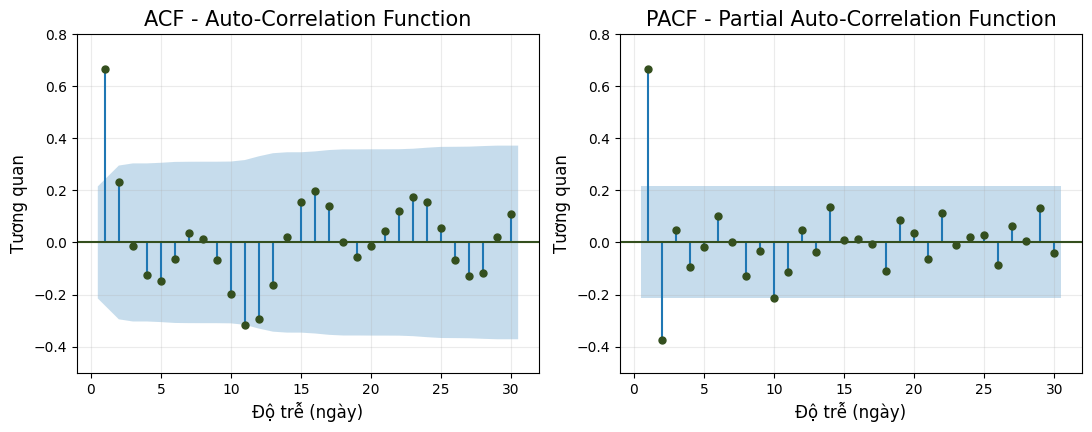

In [9]:
# log, ACF/PACF cần được quan sát trên chuỗi log, d = 0.
acf_input = log_train

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))

plot_acf(
    acf_input,
    ax=axes[0],
    lags=30,
    zero=False,
    alpha = 0.05,
    color=GREEN,
    title="ACF - Auto-Correlation Function"
)

plot_pacf(
    acf_input,
    ax=axes[1],
    lags=30,
    zero=False,
    color=GREEN,
    alpha = 0.05,
    method="ywm",
    title="PACF - Partial Auto-Correlation Function"
)

for ax in axes:
    ax.set_xlabel("Độ trễ (ngày)")
    ax.set_ylabel("Tương quan")
    ax.grid(alpha=0.25)

for ax in axes:
   ax.set_ylim(-0.5, 0.8)
    
fig.tight_layout(pad=1.0)
plt.show()

Do đây là theo ngày, nên mình sẽ thử tìm chu kỳ 7 ngày hoặc 30 ngày :<

- ACF: các giá trị gần cắt dải băng xanh khá ít, chỉ có lag 1, 11. Không có các cọc cao lặp lại theo chu kỳ => không có tính mùa vụ rõ ràng theo tuần. => q = 1

- PACF: Có một cọc đâm ngược xuống rất sâu vượt ra khỏi dải băng xanh tại lag 2. Các độ trễ sau đó hầu như nằm gọn trong vùng xanh (lag 10 bên ngoài). => p = 1

ARIMA(1, 0, 1)
SARIMA: Bị loại. 

Vì biểu đồ ACF/PACF này không hề cho thấy chu kỳ mùa vụ tuần (lag 7, 14, 21 nằm hoàn toàn trong vùng xanh), nên việc ép mô hình chạy SARIMA (ví dụ thêm `(0,0,0)[7]`) là không cần thiết, chạy vừa nặng máy mà kết quả dự báo không tốt hơn. :<<<<

## 6. Lựa chọn mô hình bằng AIC

Ta dùng `auto_arima` để tìm mô hình có AIC thấp nhất trong không gian tìm kiếm đã chỉ định.
không lấy log, lấy sai phân và chạy p, q

lấy log và chạy p, q từ 0 đến 11

In [11]:
auto_model_aic = auto_arima(
    log_train,
    start_p=0,
    start_q=0,
    max_p=11,
    max_q=11,
    # D=1,
    # max_P=2,
    # max_Q=2,
    d=0,
    #m = 24,  # Chu kỳ mùa (24 giờ)
    seasonal=False,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=False,
    max_order=None,
    with_intercept=False
)

selected_order = auto_model_aic.order

print("Best order by AIC:", selected_order)
print(f"Best AIC: {auto_model_aic.aic():.4f}")

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=464.442, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=225.650, Time=0.09 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=198.878, Time=0.16 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=166.114, Time=0.18 sec
 ARIMA(0,0,6)(0,0,0)[0]             : AIC=inf, Time=0.36 sec
 ARIMA(0,0,7)(0,0,0)[0]             : AIC=143.019, Time=0.33 sec
 ARIMA(0,0,8)(0,0,0)[0]             : AIC=inf, Time=0.57 sec
 ARIMA(0,0,9)(0,0,0)[0]             : AIC=inf, Time=0.65 sec
 ARIMA(0,0,10)(0,0,0)[0]             : AIC=126.136, Time=0.61 sec
 ARIMA(0,0,11)(0,0,0)[0]             : AIC=123.803, Time=0.67 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=67.680, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=63.460, Time=0.09 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=54.228,

## 7. Huấn luyện mô hình ARIMA được chọn

In [12]:
final_model = ARIMA(log_train, order=selected_order, trend="n")
final_result = final_model.fit()

print("Selected ARIMA order - log_train:", selected_order)
print(final_result.summary())

Selected ARIMA order - log_train: (3, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                   83
Model:                 ARIMA(3, 0, 1)   Log Likelihood                 -21.542
Date:                Tue, 05 May 2026   AIC                             53.084
Time:                        03:38:50   BIC                             65.178
Sample:                    01-01-2026   HQIC                            57.943
                         - 03-24-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.9280      0.096     20.142      0.000       1.740       2.116
ar.L2         -1.2973      0.212     -6.118      0.000      -1.713      -0.882
ar.L3   

## 8. Chẩn đoán phần dư

Ta kiểm tra phần dư bằng chuỗi phần dư theo thời gian, ACF phần dư và kiểm định Ljung–Box.

Selected ARIMA order: (3, 0, 1)
model_df = p + q = 4
      lb_stat  lb_pvalue
15   8.956097   0.625945
20  12.025453   0.742226
30  17.643308   0.888363
Selected ARIMA order: (3, 0, 1)
model_df = p + q = 4
      lb_stat  lb_pvalue
5    2.328882   0.126993
6    2.928031   0.231306
7    4.312035   0.229682
8    5.192143   0.268144
9    5.217810   0.389881
10   6.765238   0.343105
11   7.335633   0.394790
12   8.003371   0.433141
13   8.385773   0.495785
14   8.787399   0.552392
15   8.956097   0.625945
16   9.005334   0.702475
17   9.109212   0.764646
18   9.123066   0.823087
19  11.259224   0.734011
20  12.025453   0.742226
21  13.681810   0.689483
22  15.439225   0.631621
23  15.544099   0.687446
24  15.874001   0.724410
25  16.152227   0.761038
26  16.286605   0.801411
27  16.295881   0.842313
28  17.626015   0.820765
29  17.642999   0.857165
30  17.643308   0.888363
31  17.696367   0.912526
32  18.112461   0.923281
33  18.326089   0.937355
34  18.689730   0.946267
35  21.048556   0.9

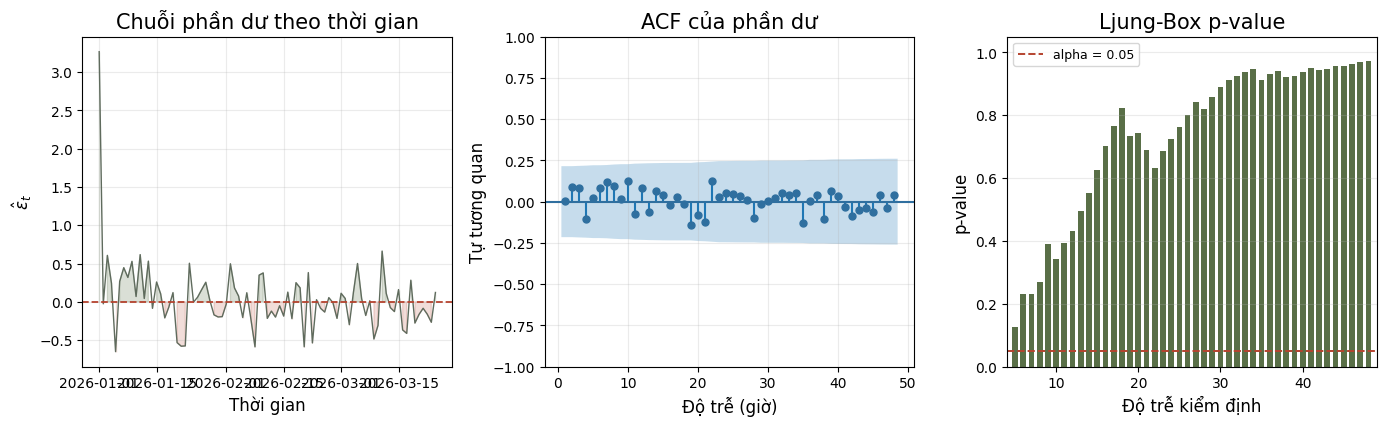

In [13]:
residuals = final_result.resid.dropna()

# Với residual của ARIMA, nên hiệu chỉnh bậc tự do theo p + q.
# Không dùng lag <= model_df vì khi đó p-value Ljung-Box không còn ý nghĩa.
model_df = selected_order[0] + selected_order[2]
valid_lags = [lag for lag in [15, 20, 30] if lag > model_df]

ljung_box_result = acorr_ljungbox(
    residuals,
    lags=valid_lags,
    model_df=model_df,
    return_df=True
)

print("Selected ARIMA order:", selected_order)
print("model_df = p + q =", model_df)
print(ljung_box_result)
residuals = final_result.resid.dropna()

model_df = selected_order[0] + selected_order[2]
max_lag = 48

# Chỉ lấy các lag hợp lệ cho Ljung-Box
lb_lags = list(range(model_df + 1, max_lag + 1))
if not lb_lags:
    raise ValueError(
        f"model_df = {model_df} đang >= max_lag = {max_lag}, "
        "không còn lag hợp lệ cho Ljung-Box."
    )

ljung_box_result = acorr_ljungbox(
    residuals,
    lags=lb_lags,
    model_df=model_df,
    return_df=True
)

print("Selected ARIMA order:", selected_order)
print("model_df = p + q =", model_df)
print(ljung_box_result)

from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf

resid_values = residuals.to_numpy(dtype=float)
resid_time = residuals.index

lags_full = ljung_box_result.index.to_numpy()
pvals_full = ljung_box_result["lb_pvalue"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))

axes[0].plot(resid_time, resid_values, color=GRAY, linewidth=1.0)
axes[0].axhline(0, color=RED, linestyle="--", linewidth=1.3)
axes[0].fill_between(
    resid_time, 0, resid_values,
    where=(resid_values >= 0),
    color=GREEN, alpha=0.18
)
axes[0].fill_between(
    resid_time, 0, resid_values,
    where=(resid_values < 0),
    color=RED, alpha=0.18
)
axes[0].set_title("Chuỗi phần dư theo thời gian")
axes[0].set_xlabel("Thời gian")
axes[0].set_ylabel(r"$\hat{\varepsilon}_t$")
axes[0].grid(alpha=0.25)

sm_plot_acf(
    residuals,
    ax=axes[1],
    lags=max_lag,
    zero=False,
    color=BLUE,
    alpha=0.05
)
axes[1].set_title("ACF của phần dư")
axes[1].set_xlabel("Độ trễ (giờ)")
axes[1].set_ylabel("Tự tương quan")
axes[1].grid(alpha=0.25)

axes[2].bar(
    lags_full,
    pvals_full,
    color=[GREEN if p > 0.05 else RED for p in pvals_full],
    alpha=0.82,
    width=0.7
)
axes[2].axhline(0.05, color=RED, linestyle="--", linewidth=1.4, label="alpha = 0.05")
axes[2].set_title("Ljung-Box p-value")
axes[2].set_xlabel("Độ trễ kiểm định")
axes[2].set_ylabel("p-value")
axes[2].set_xlim(model_df, max_lag + 1)
axes[2].set_ylim(0, 1.05)
axes[2].legend(frameon=True, fontsize=9)
axes[2].grid(axis="y", alpha=0.25)

fig.tight_layout(pad=1.2)
plt.show()

Phần dư: 
- Các gt dao động quanh mức 0, không có xu hướng rõ rệt nào bị bỏ sót lại --> nắm bắt tốt mặt bằng chung của dữ liệu 
- Một số điểm ở mức -30, khá đtrung ở chất lượng không khí vì bụi mịn thường có các đợt drift do các yếu tố ngoại sinh 

ACF: hầu hết các chấm nằm trong khoảng tin cậy ==> Gần với nhiễu trắng 
Nếu phần dư dao động quanh 0, ACF phần dư hầu hết nằm trong khoảng tin cậy và các p-value Ljung–Box lớn hơn 0.05, mô hình có thể được xem là đạt yêu cầu chẩn đoán.


## 9. Dự báo trên tập kiểm tra

Sau khi mô hình đạt yêu cầu ở bước chẩn đoán phần dư, ta dự báo trên tập kiểm tra và đánh giá sai số.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Lấy kết quả dự báo (Đang ở dạng Log)
n_steps = len(test)
forecast_result = final_result.get_forecast(steps=n_steps)

forecast_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()

# 2. KHÔI PHỤC DỮ LIỆU TỪ LOG VỀ ĐƠN VỊ THỰC TẾ (Quan trọng nhất!)
forecast = np.exp(forecast_log)
conf_int = np.exp(conf_int_log)

# Gắn lại index thời gian
forecast.index = test.index
conf_int.index = test.index

# 3. Tính toán các chỉ số đánh giá
# Chú ý: Đảm bảo biến 'test' lúc này đang chứa dữ liệu PM2.5 gốc (chưa log)
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast) # Dùng thư viện cho nhanh gọn

# Tính MAPE
# Cách 1: Tự code có chống lỗi chia 0 (Cách bạn đang dùng)
nonzero_mask = test != 0
mape_custom = np.mean(
    np.abs((test[nonzero_mask] - forecast[nonzero_mask]) / test[nonzero_mask])
) * 100

# Cách 2: Dùng thư viện sklearn (Kết quả thường trả về dạng thập phân 0.x, nên nhân 100)
# mape_sklearn = mean_absolute_percentage_error(test, forecast) * 100

print(f"=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===")
print(f"MAE  : {mae:.2f} µg/m³")
print(f"RMSE : {rmse:.2f} µg/m³")
print(f"MAPE : {mape_custom:.2f}%")
print(f"R²   : {r2:.4f}")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===
MAE  : 10.02 µg/m³
RMSE : 11.63 µg/m³
MAPE : 20.92%
R²   : -0.0169


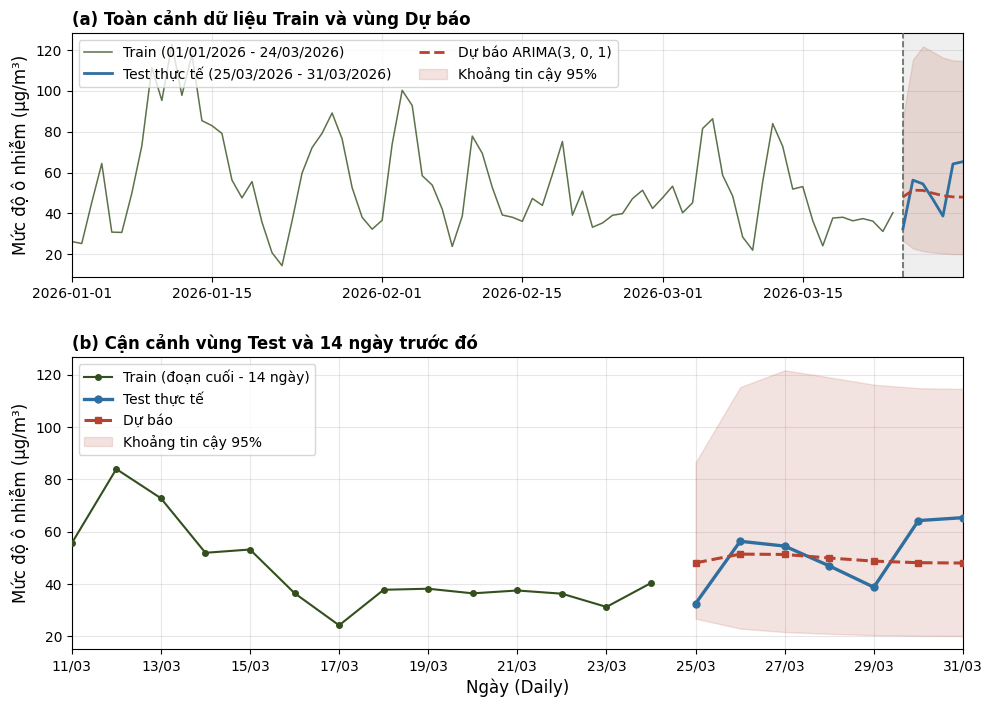

In [15]:
import matplotlib.dates as mdates

train_time = train.index
test_time = test.index

y_train = train.to_numpy()
y_test = test.to_numpy()
fc_arr = np.asarray(forecast, dtype=float).ravel()
lower = conf_int.iloc[:, 0].to_numpy()
upper = conf_int.iloc[:, 1].to_numpy()

# Format ngày để in trên legend (chỉ lấy YYYY-MM-DD)
train_start = train_time[0].strftime('%d/%m/%Y')
train_end = train_time[-1].strftime('%d/%m/%Y')
test_start = test_time[0].strftime('%d/%m/%Y')
test_end = test_time[-1].strftime('%d/%m/%Y')

order_lbl = f"({selected_order[0]}, {selected_order[1]}, {selected_order[2]})"

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(11.5, 8.0), sharey=False,
    gridspec_kw={"height_ratios": [1.0, 1.2], "hspace": 0.3}
)

# ==========================================
# Subplot 1: TỔNG QUAN
# ==========================================
ax0.plot(train_time, y_train, color=GREEN, linewidth=1.1, alpha=0.8,
         label=f"Train ({train_start} - {train_end})")
ax0.plot(test_time, y_test, color=BLUE, linewidth=2.0,
         label=f"Test thực tế ({test_start} - {test_end})", zorder=4)
ax0.plot(test_time, fc_arr, color=RED, linewidth=2.0, linestyle="--",
         label=f"Dự báo ARIMA{order_lbl}", zorder=5)
ax0.fill_between(test_time, lower, upper, color=RED, alpha=0.15, zorder=2,
                 label="Khoảng tin cậy 95%")

# Tạo một dải màu mờ đánh dấu vùng Test
ax0.axvspan(test_time[0], test_time[-1], color=GRAY, alpha=0.1, zorder=0)
ax0.axvline(test_time[0], color=GRAY, linestyle="--", linewidth=1.2, zorder=3)

ax0.set_ylabel("Mức độ ô nhiễm (µg/m³)")
ax0.set_title("(a) Toàn cảnh dữ liệu Train và vùng Dự báo", loc="left", fontsize=12, fontweight='bold')
ax0.legend(loc="upper left", frameon=True, fontsize=10, ncol=2)
ax0.grid(alpha=0.3)
ax0.set_xlim(train_time[0], test_time[-1])

# ==========================================
# Subplot 2: PHÓNG TO VÙNG TEST
# ==========================================
# Chỉnh lại khoảng Zoom: Lấy 14 ngày (2 tuần) trước vùng test thay vì 48
zoom_lookback = 14 
z_lo = train_time[-zoom_lookback] if len(train_time) >= zoom_lookback else train_time[0]
z_hi = test_time[-1]
mask = train_time >= z_lo

ax1.plot(train_time[mask], y_train[mask], color=GREEN, linewidth=1.5, marker="o", markersize=4,
         label=f"Train (đoạn cuối - {zoom_lookback} ngày)", zorder=3)
ax1.plot(test_time, y_test, color=BLUE, linewidth=2.4, marker="o", markersize=5,
         label="Test thực tế", zorder=5)
ax1.plot(test_time, fc_arr, color=RED, linewidth=2.2, linestyle="--",
         marker="s", markersize=5, label="Dự báo", zorder=5)
ax1.fill_between(test_time, lower, upper, color=RED, alpha=0.15, zorder=2,
                 label="Khoảng tin cậy 95%")

ax1.set_xlabel("Ngày (Daily)")
ax1.set_ylabel("Mức độ ô nhiễm (µg/m³)")
ax1.set_title(f"(b) Cận cảnh vùng Test và {zoom_lookback} ngày trước đó", loc="left", fontsize=12, fontweight='bold')
ax1.legend(loc="upper left", frameon=True, fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(z_lo, z_hi)

# Format lại hiển thị ngày trên trục hoành cho đỡ sát nhau
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=0)

# Hiển thị metrics nếu có (Bạn nhớ tính mae, rmse, mape trước khi gọi dòng này nhé)
try:
    metrics = f"Kết quả đánh giá: MAE = {mae:.1f} | RMSE = {rmse:.1f} | MAPE = {mape:.1f}%"
    fig.suptitle(metrics, fontsize=14, fontweight='bold', color='darkred', y=0.98)
except NameError:
    pass # Bỏ qua nếu chưa tính metrics

fig.tight_layout(pad=1.5, rect=[0, 0, 1, 0.96])
plt.show()

## 10.5 ARIMA-GARCH: Mô hình hóa volatility thay đổi theo thời gian
GARCH (Generalized Autoregressive Conditional Heteroskedasticity) giúp capture sự thay đổi của độ lệch chuẩn (volatility) trong phần dư. 

**Ý tưởng:**
- ARIMA: Dự báo **giá trị trung bình** (mean)
- GARCH: Dự báo **độ biến động** (conditional variance) của phần dư

Kết hợp lại → Confidence Intervals động, không cố định như 95%.

In [16]:
# Cài đặt arch package nếu chưa có
! pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 39.9 MB/s eta 0:00:00


In [17]:
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. Lấy residuals từ ARIMA đã fit
# ============================================
arima_resid = final_result.resid  # Đã có từ cell chẩn đoán

print(f"Residuals ARIMA - Thống kê cơ bản:")
print(f"  Mean: {arima_resid.mean():.6f}")
print(f"  Std:  {arima_resid.std():.6f}")
print(f"  Min:  {arima_resid.min():.6f}")
print(f"  Max:  {arima_resid.max():.6f}")

# ============================================
# 2. Fit GARCH(1,1) trên residuals
# ============================================
# GARCH(1,1): Variance ở t phụ thuộc vào:
#   - Shock quá khứ (bậc 1): Squared residual tại t-1
#   - Conditional variance quá khứ (bậc 1): Variance tại t-1

model_garch = arch_model(arima_resid.dropna(), vol='Garch', p=1, q=1)
results_garch = model_garch.fit(disp='off')

print("\n" + "="*60)
print("GARCH(1,1) Summary:")
print("="*60)
print(results_garch.summary())

Residuals ARIMA - Thống kê cơ bản:
  Mean: 0.036986
  Std:  0.472388
  Min:  -0.651381
  Max:  3.268618

GARCH(1,1) Summary:
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -27.1266
Distribution:                  Normal   AIC:                           62.2532
Method:            Maximum Likelihood   BIC:                           71.9286
                                        No. Observations:                   83
Date:                Tue, May 05 2026   Df Residuals:                       82
Time:                        03:38:57   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
--------

In [18]:
# --- Giả sử `results_garch`, `forecast_result`, `conf_int_log` đã có ---
# 1) Lấy forecast trong không gian log (đúng với ARIMA đã fit trên log)
forecast_log = forecast_result.predicted_mean    # ln(y_hat)

# 2) Lấy variance/std từ GARCH (đã là variance của residuals ở không gian log)
garch_variance = results_garch.forecast(horizon=n_steps).variance.values[-1, :]
garch_std = np.sqrt(garch_variance)

z_score = 1.96  # 95%

# 3) Tạo CI trong không gian log, rồi đảo về scale gốc
lower_garch = np.exp(forecast_log - z_score * garch_std)
upper_garch = np.exp(forecast_log + z_score * garch_std)

# 4) Point forecast: median của phân phối log-normal
forecast_mean = np.exp(forecast_log)

# -- Nếu muốn dùng expected value của Y khi ln(Y) ~ N(mu, sigma^2):
# forecast_mean_expectation = np.exp(forecast_log + 0.5 * garch_variance)

# 5) CI cố định từ ARIMA (chú ý: conf_int_log là CI ở không gian log)
lower_arima = np.exp(conf_int_log.iloc[:, 0].values)
upper_arima = np.exp(conf_int_log.iloc[:, 1].values)

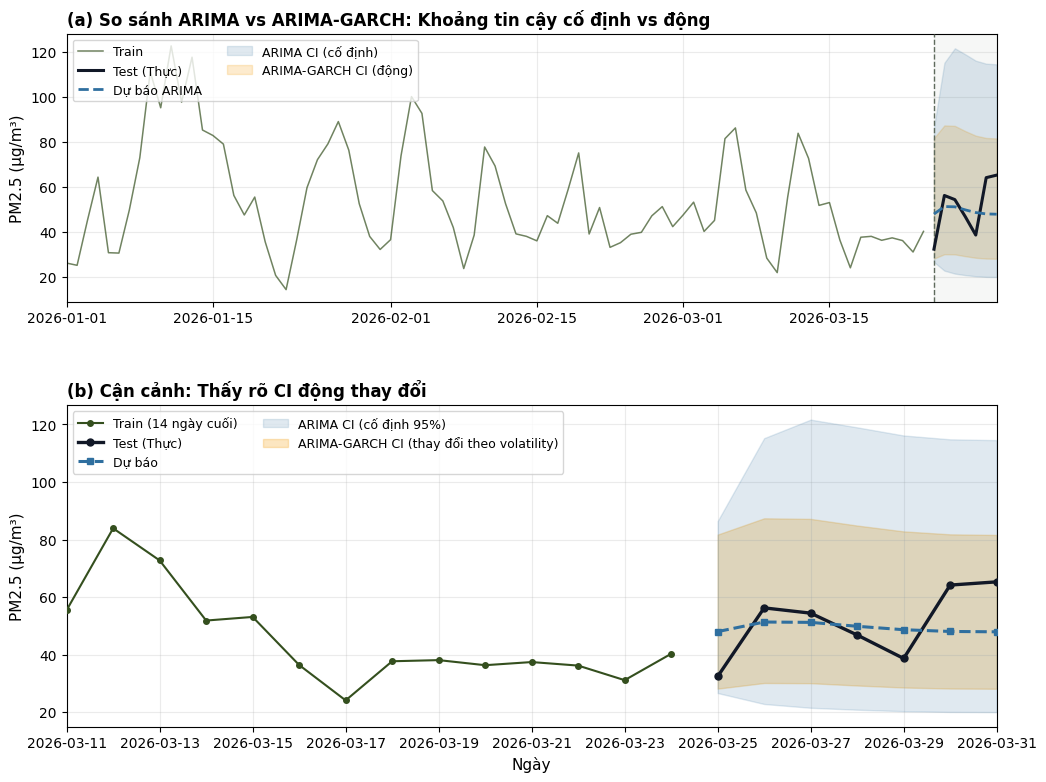


✓ Đô rộng CI - ARIMA (cố định): 59.72 µg/m³
✓ Đô rộng CI - GARCH (động):  từ 53.43 đến 57.21 µg/m³


In [20]:
# ============================================
# 5. Vẽ so sánh: ARIMA (CI cố định) vs ARIMA-GARCH (CI động)
# ============================================

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12.0, 9.0), sharey=False,
                               gridspec_kw={"height_ratios": [1.0, 1.2], "hspace": 0.35})

train_time = train.index
test_time = test.index
y_train = train.values.astype(float)
y_test = test.values.astype(float)

# ==========================================
# Subplot 1: Toàn cảnh
# ==========================================
ax0.plot(train_time, y_train, color=GREEN, linewidth=1.1, alpha=0.7,
         label="Train")
ax0.plot(test_time, y_test, color=DARK, linewidth=2.2,
         label="Test (Thực)", zorder=5)
ax0.plot(test_time, forecast_mean, color=BLUE, linewidth=2.0, linestyle="--",
         label="Dự báo ARIMA", zorder=5)

# CI cố định từ ARIMA
ax0.fill_between(test_time, lower_arima, upper_arima, color=BLUE, alpha=0.15, 
                 label="ARIMA CI (cố định)", zorder=2)

# CI động từ GARCH
ax0.fill_between(test_time, lower_garch, upper_garch, color=ORANGE, alpha=0.2, 
                 label="ARIMA-GARCH CI (động)", zorder=1)

ax0.axvspan(test_time[0], test_time[-1], color=GRAY, alpha=0.05, zorder=0)
ax0.axvline(test_time[0], color=GRAY, linestyle="--", linewidth=1, zorder=3)

ax0.set_ylabel("PM2.5 (µg/m³)", fontsize=11)
ax0.set_title("(a) So sánh ARIMA vs ARIMA-GARCH: Khoảng tin cậy cố định vs động", 
              loc="left", fontsize=12, fontweight='bold')
ax0.legend(loc="upper left", frameon=True, fontsize=9, ncol=2)
ax0.grid(alpha=0.25)
ax0.set_xlim(train_time[0], test_time[-1])

# ==========================================
# Subplot 2: Phóng to vùng test
# ==========================================
z_lo = train_time[-14] if len(train_time) >= 14 else train_time[0]
z_hi = test_time[-1]
mask = train_time >= z_lo

ax1.plot(train_time[mask], y_train[mask], color=GREEN, linewidth=1.5, marker="o", markersize=4,
         label="Train (14 ngày cuối)", zorder=3)
ax1.plot(test_time, y_test, color=DARK, linewidth=2.4, marker="o", markersize=5,
         label="Test (Thực)", zorder=5)
ax1.plot(test_time, forecast_mean, color=BLUE, linewidth=2.2, linestyle="--",
         marker="s", markersize=5, label="Dự báo", zorder=5)

# CI cố định (Blue band)
ax1.fill_between(test_time, lower_arima, upper_arima, color=BLUE, alpha=0.15, 
                 label="ARIMA CI (cố định 95%)", zorder=2)

# CI động (Orange band) - Lưu ý: CI này thay đổi chiều rộng theo thời gian
ax1.fill_between(test_time, lower_garch, upper_garch, color=ORANGE, alpha=0.25,
                 label="ARIMA-GARCH CI (thay đổi theo volatility)", zorder=1)

ax1.set_xlabel("Ngày", fontsize=11)
ax1.set_ylabel("PM2.5 (µg/m³)", fontsize=11)
ax1.set_title("(b) Cận cảnh: Thấy rõ CI động thay đổi", loc="left", fontsize=12, fontweight='bold')
ax1.legend(loc="upper left", frameon=True, fontsize=9, ncol=2)
ax1.grid(alpha=0.25)
ax1.set_xlim(z_lo, z_hi)

fig.tight_layout()
plt.show()

print(f"\n✓ Đô rộng CI - ARIMA (cố định): {(upper_arima[0] - lower_arima[0]):.2f} µg/m³")
print(f"✓ Đô rộng CI - GARCH (động):  từ {(upper_garch - lower_garch).min():.2f} đến {(upper_garch - lower_garch).max():.2f} µg/m³")


In [21]:
# ============================================
# 6. Đánh giá: ARIMA-GARCH có cải thiện không?
# ============================================

# ARIMA-GARCH vẫn dùng forecast từ ARIMA → Metrics dự báo vẫn giống
# Khác biệt: Confidence Intervals thay đổi theo volatility

# So sánh độ rộng CI:
ci_width_arima = (upper_arima - lower_arima).mean()
ci_width_garch = (upper_garch - lower_garch).mean()

print("\n" + "="*70)
print("ARIMA vs ARIMA-GARCH: Comparison")
print("="*70)

print(f"\nForecast Accuracy (giống nhau - cả hai dùng ARIMA mean):")
print(f"  MAE:  {mae:.2f} µg/m³")
print(f"  RMSE: {rmse:.2f} µg/m³")
print(f"  MAPE: {mape_custom:.2f}%")
print(f"  R²:   {r2:.4f}")

print(f"\nConfidence Interval Width (GARCH thay đổi theo thời gian):")
print(f"  ARIMA (cố định 95%):      {ci_width_arima:.2f} µg/m³ (không đổi)")
print(f"  ARIMA-GARCH (động):       {ci_width_garch:.2f} µg/m³ (trung bình)")
print(f"    - Min width: {(upper_garch - lower_garch).min():.2f} µg/m³")
print(f"    - Max width: {(upper_garch - lower_garch).max():.2f} µg/m³")

print(f"\nLợi ích của ARIMA-GARCH:")
print(f"  ✓ Capture volatility clustering (giai đoạn ô nhiễm cao → KTC rộng hơn)")
print(f"  ✓ Confidence intervals động, phản ánh conditional variance")
print(f"  ✓ Không thay đổi forecast value, chỉ cải thiện uncertainty quantification")

# Kiểm tra % test values nằm trong CI
in_ci_arima = np.sum((y_test >= lower_arima) & (y_test <= upper_arima)) / len(test) * 100
in_ci_garch = np.sum((y_test >= lower_garch) & (y_test <= upper_garch)) / len(test) * 100

print(f"\n% Test values nằm trong CI:")
print(f"  ARIMA CI:      {in_ci_arima:.1f}% ({in_ci_arima:.0f}/{len(test)} điểm)")
print(f"  ARIMA-GARCH CI: {in_ci_garch:.1f}% ({in_ci_garch:.0f}/{len(test)} điểm)")
if in_ci_garch >= in_ci_arima:
    print(f"  → GARCH tốt hơn (coverage cao hơn)")
else:
    print(f"  → ARIMA tốt hơn (CI không quá rộng)")


ARIMA vs ARIMA-GARCH: Comparison

Forecast Accuracy (giống nhau - cả hai dùng ARIMA mean):
  MAE:  10.02 µg/m³
  RMSE: 11.63 µg/m³
  MAPE: 20.92%
  R²:   -0.0169

Confidence Interval Width (GARCH thay đổi theo thời gian):
  ARIMA (cố định 95%):      90.74 µg/m³ (không đổi)
  ARIMA-GARCH (động):       54.94 µg/m³ (trung bình)
    - Min width: 53.43 µg/m³
    - Max width: 57.21 µg/m³

Lợi ích của ARIMA-GARCH:
  ✓ Capture volatility clustering (giai đoạn ô nhiễm cao → KTC rộng hơn)
  ✓ Confidence intervals động, phản ánh conditional variance
  ✓ Không thay đổi forecast value, chỉ cải thiện uncertainty quantification

% Test values nằm trong CI:
  ARIMA CI:      100.0% (100/7 điểm)
  ARIMA-GARCH CI: 100.0% (100/7 điểm)
  → GARCH tốt hơn (coverage cao hơn)


## ARIMAX - 8 biến ngoại sinh

Đang huấn luyện ARIMAX(3, 0, 1) với 8 biến ngoại sinh...
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -9.0094     12.811     -0.703      0.482     -34.118      16.100
Temperature           0.0543      0.017      3.111      0.002       0.020       0.089
Clouds               -0.0018      0.001     -1.527      0.127      -0.004       0.001
Wind Speed           -0.0416      0.015     -2.693      0.007      -0.072      -0.011
Precipitation         0.0531      0.139      0.381      0.703      -0.220       0.326
Pressure              0.0111      0.012      0.917      0.359      -0.013       0.035
Relative Humidity    -0.0003      0.005     -0.059      0.953      -0.010       0.010
SO2                   0.0189      0.007      2.816      0.005       0.006       0.032
NO2                   0.0089      0.006      1.420      0.156      -0.003       0.0

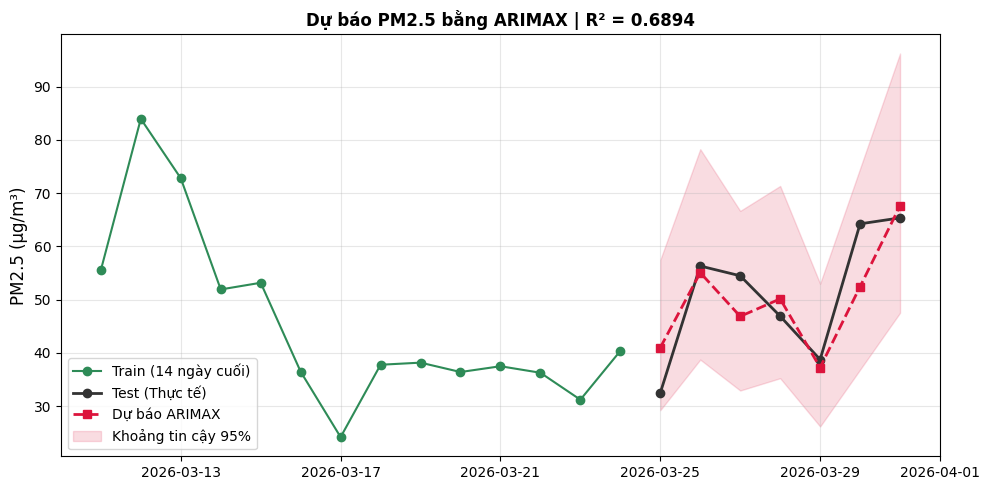

In [22]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU NỘI SINH VÀ NGOẠI SINH
# ==========================================
TARGET_COL = 'PM25'
# Chọn lọc các biến ngoại sinh thực sự có tác động (tránh nhiễu)
# exog_cols = ['Wind Speed', 'Precipitation', 'SO2', 'NO2']
exog_cols = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity', 'SO2', 'NO2']

# Đọc file CSV
train_env = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-daily-xgb/PM25_2026_Q1_train_daily.csv")
test_env = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-daily-xgb/PM25_2026_Q1_test_daily.csv")

# 1. Chuyển cột Local Time sang định dạng chuẩn Datetime
train_env['Local Time'] = pd.to_datetime(train_env['Local Time'])
test_env['Local Time'] = pd.to_datetime(test_env['Local Time'])

train_env.set_index('Local Time', inplace=True)
test_env.set_index('Local Time', inplace=True)

train_env = train_env.asfreq('D')
test_env = test_env.asfreq('D')

# Lấy dữ liệu ngoại sinh (Exogenous variables)
exog_train = train_env[exog_cols]
exog_test  = test_env[exog_cols]

# Lấy dữ liệu nội sinh (Endogenous variable) và chuyển sang LOG
endog_train_log = np.log(train_env[TARGET_COL])
endog_test_raw  = test_env[TARGET_COL] # Giữ nguyên gốc để lát so sánh lỗi

# ==========================================
# 2. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH ARIMAX
# ==========================================
# Dùng lại order (3, 0, 1) hoặc (2, 0, 0) mà bạn đã tìm ra trước đó
selected_order = (3, 0, 1)

print(f"Đang huấn luyện ARIMAX{selected_order} với {len(exog_cols)} biến ngoại sinh...")

model_arimax = ARIMA(
    endog=endog_train_log, 
    exog=exog_train,       # <--- ĐIỂM KHÁC BIỆT: Truyền thêm biến ngoại sinh vào đây
    order=selected_order
)
results_arimax = model_arimax.fit()

print(results_arimax.summary().tables[1]) # In bảng hệ số để xem biến thời tiết nào có ý nghĩa

# ==========================================
# 3. DỰ BÁO TẬP TEST
# ==========================================
n_steps = len(test_env)

# Khi dự báo, BẮT BUỘC phải cung cấp dữ liệu ngoại sinh của tương lai (tập test)
forecast_result = results_arimax.get_forecast(steps=n_steps, exog=exog_test)

# Lấy kết quả dự báo (Đang ở dạng Log)
forecast_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()

# KHÔI PHỤC VỀ KHÔNG GIAN THỰC (np.exp)
forecast_arimax = np.exp(forecast_log)
lower_arimax = np.exp(conf_int_log.iloc[:, 0])
upper_arimax = np.exp(conf_int_log.iloc[:, 1])

forecast_arimax.index = test_env.index

# ==========================================
# 4. ĐÁNH GIÁ CHỈ SỐ METRICS
# ==========================================
mae = mean_absolute_error(endog_test_raw, forecast_arimax)
rmse = np.sqrt(mean_squared_error(endog_test_raw, forecast_arimax))
r2 = r2_score(endog_test_raw, forecast_arimax)

nonzero_mask = endog_test_raw != 0
mape = np.mean(np.abs((endog_test_raw[nonzero_mask] - forecast_arimax[nonzero_mask]) / endog_test_raw[nonzero_mask])) * 100

print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ ARIMAX")
print("="*40)
print(f"MAE  : {mae:.2f} µg/m³")
print(f"RMSE : {rmse:.2f} µg/m³")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# ==========================================
# 5. VẼ ĐỒ THỊ TRỰC QUAN (Phóng to vùng Test)
# ==========================================
plt.figure(figsize=(10, 5))

# Zoom vào 14 ngày cuối của train cho dễ nhìn
zoom_days = 14
train_plot = train_env[TARGET_COL].iloc[-zoom_days:]

plt.plot(train_plot.index, train_plot.values, color='seagreen', marker='o', label='Train (14 ngày cuối)')
plt.plot(endog_test_raw.index, endog_test_raw.values, color='#333333', marker='o', linewidth=2, label='Test (Thực tế)')
plt.plot(forecast_arimax.index, forecast_arimax.values, color='crimson', marker='s', linestyle='--', linewidth=2, label='Dự báo ARIMAX')

plt.fill_between(forecast_arimax.index, lower_arimax, upper_arimax, color='crimson', alpha=0.15, label='Khoảng tin cậy 95%')

plt.title(f"Dự báo PM2.5 bằng ARIMAX | R² = {r2:.4f}", fontsize=12, fontweight='bold')
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Đọc DL

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
train_valid = pd.read_csv('/kaggle/input/datasets/binhdanghai/data-daily-xgb/PM25_2026_Q1_train_daily.csv')
test = pd.read_csv('/kaggle/input/datasets/binhdanghai/data-daily-xgb/PM25_2026_Q1_test_daily.csv')

In [25]:
print("Train - Valid shape:", train_valid.shape)
print("Test shape:", test.shape)

Train - Valid shape: (83, 14)
Test shape: (7, 14)


In [26]:
print("======= DATA INFO =======")
print(train_valid.info())

======= DATA INFO =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Time         83 non-null     object 
 1   AQI                83 non-null     float64
 2   CO                 83 non-null     float64
 3   NO2                83 non-null     float64
 4   O3                 83 non-null     float64
 5   PM10               83 non-null     float64
 6   PM25               83 non-null     float64
 7   SO2                83 non-null     float64
 8   Clouds             83 non-null     float64
 9   Precipitation      83 non-null     float64
 10  Pressure           83 non-null     float64
 11  Relative Humidity  83 non-null     float64
 12  Temperature        83 non-null     float64
 13  Wind Speed         83 non-null     float64
dtypes: float64(13), object(1)
memory usage: 9.2+ KB
None


In [27]:
train_valid.head(5)

,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,2026-01-01,103.375000,664.375000,25.891667,62.333333,26.875000,26.275000,30.366667,94.666667,0.191667,1014.554167,87.250000,19.558333,11.850000
1,2026-01-02,69.125000,878.083333,22.833333,35.166667,25.516667,25.283333,36.200000,100.000000,0.041667,1021.179167,76.000000,15.708333,11.158333
2,2026-01-03,96.083333,766.958333,37.145833,25.875000,45.687500,45.412500,50.358333,96.083333,0.000000,1021.370833,73.708333,15.950000,6.583333
3,2026-01-04,148.708333,950.458333,55.425000,29.125000,65.187500,64.450000,57.050000,90.541667,0.012500,1018.758333,83.500000,17.437500,5.158333
4,2026-01-05,135.666667,806.125000,29.833333,30.541667,31.312500,30.883333,34.787500,99.958333,0.054167,1020.762500,80.000000,15.750000,11.941667


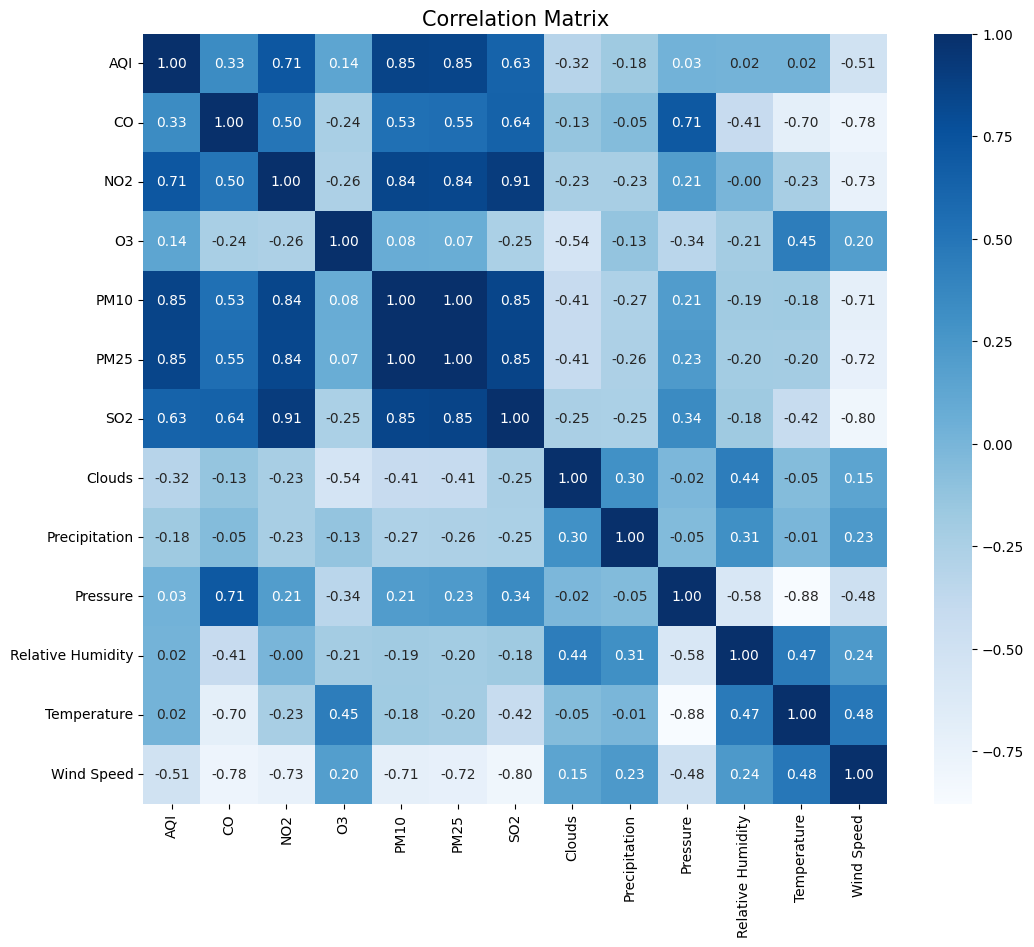

In [28]:
# Ma trận tương quan giữa các biến định lượng
numeric_columns = train_valid.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()



# Feature Engineering
XGBoost cần thôi còn LSTM không cần

In [29]:
from statsmodels.tsa.seasonal import MSTL
from sklearn.preprocessing import StandardScaler

In [30]:
# Hàm trích xuất quy luật mùa vụ (chỉ dùng cho tập train - Dữ liệu Daily)
def extract_seasonal_profiles(df):
    df_new = df.copy()
    
    df_new['Local Time'] = pd.to_datetime(df_new['Local Time'])
        
    # Phân rã MSTL: Chỉ còn chu kỳ 7 ngày (Weekly)
    mstl_model = MSTL(df_new['PM25'], periods=[7])
    res = mstl_model.fit()

    # MSTL với 1 chu kỳ sẽ trả về pandas Series
    df_new['seasonal_7'] = res.seasonal
    
    # Xóa toàn bộ logic liên quan đến giờ (hour), chỉ giữ lại Thứ và Tháng
    df_new['day_of_week'] = df_new['Local Time'].dt.dayofweek
    df_new['month'] = df_new['Local Time'].dt.month
    
    # Ghép Tháng và Thứ để xem quy luật các ngày trong tuần thay đổi thế nào qua từng tháng
    df_new['month_weekday'] = df_new['month'].astype(str) + "_" + df_new['day_of_week'].astype(str)
    
    # Tính trung bình tính mùa vụ
    profile_7 = df_new.groupby('month_weekday')['seasonal_7'].mean().to_dict()
    
    return profile_7

In [31]:
import pandas as pd

# Hàm trích chọn đặc trưng (dùng cho dữ liệu Daily)
def extract_features(df, profile_7, use_env=True):
    df_new = df.copy()
    
    # Chuyển định dạng ngày tháng
    df_new['Local Time'] = pd.to_datetime(df_new['Local Time'])
    
    # Tạo các đặc trưng về thời gian 
    df_new['day_of_week'] = df_new['Local Time'].dt.dayofweek
    df_new['month'] = df_new['Local Time'].dt.month
    df_new['season'] = df_new['month'].apply(lambda x: (x%12 + 4)//3)  
    df_new['is_dry_season'] = df_new['month'].isin([11, 12, 1, 2, 3, 4]).astype(int)    
    df_new['is_weekend'] = df_new['day_of_week'].isin([5, 6]).astype(int)
    
    # Map quy luật mùa vụ đã trích xuất từ tập train (Chu kỳ 7 ngày)
    df_new['month_weekday'] = df_new['month'].astype(str) + "_" + df_new['day_of_week'].astype(str)
    df_new['seasonal_7'] = df_new['month_weekday'].map(profile_7)
    df_new.drop(columns=['month_weekday'], inplace=True) # Xóa cột trung gian
        
    # Tạo các đặc trưng về lag (1 step = 1 ngày)
    df_new['pm25_lag1'] = df_new['PM25'].shift(1)      # Lùi 1 ngày
    df_new['pm25_lag7'] = df_new['PM25'].shift(7)      # Lùi 7 ngày (1 tuần)
    
    # Tạo các đặc trưng về rolling (thêm shift để tránh data leakage)
    df_new['pm25_rolling_3d']  = df_new['PM25'].rolling(window=3).mean().shift(1)  # Trung bình 3 ngày
    df_new['pm25_rolling_7d']  = df_new['PM25'].rolling(window=7).mean().shift(1)  # Trung bình 7 ngày
    df_new['pm25_rolling_7d_std'] = df_new['PM25'].rolling(window=7).std().shift(1) # Độ lệch chuẩn 7 ngày
    
    # Cập nhật lại danh sách base_features
    base_features = ['day_of_week', 'month', 'season', 'is_dry_season', 'is_weekend',
                     'seasonal_7',
                     'pm25_lag1', 'pm25_lag7',
                     'pm25_rolling_3d', 'pm25_rolling_7d', 'pm25_rolling_7d_std']
    
    env_features = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity']
    
    features = (env_features + base_features) if use_env else base_features
    return df_new, features

In [32]:
import pandas as pd

# Hàm chuẩn bị dữ liệu (Dùng cho dữ liệu Daily)
# Thêm 2 tham số valid_start và test_start để linh hoạt chia tập dữ liệu
def prepare_data(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', use_env=True):
    # Lọc tập train dựa trên mốc thời gian linh hoạt
    train = train_valid[train_valid['Local Time'] < valid_start].copy()
    
    # ---> ĐIỂM SỬA 1: Chỉ còn nhận 1 biến profile_7 từ hàm phân rã MSTL
    profile_7 = extract_seasonal_profiles(train)
    
    # Gộp dữ liệu để tính Lag/Rolling không bị hụt ở đầu tập Valid/Test
    combined = pd.concat([train_valid, test], ignore_index=True)
    combined.sort_values('Local Time', inplace=True)    # Sắp xếp theo thời gian
    combined.reset_index(drop=True, inplace=True)       # Cập nhật lại index
    
    # ---> ĐIỂM SỬA 2: Truyền đúng biến profile_7 vào hàm trích chọn đặc trưng
    data_prepared, features = extract_features(combined, profile_7, use_env)
    
    # Chia lại train, valid, test dựa trên mốc thời gian mới
    train = data_prepared[data_prepared['Local Time'] < valid_start].copy()
    valid = data_prepared[(data_prepared['Local Time'] >= valid_start) & (data_prepared['Local Time'] < test_start)].copy()
    test  = data_prepared[data_prepared['Local Time'] >= test_start].copy()
    
    # Xóa các hàng có giá trị NaN do việc tạo đặc trưng lag và rolling (Chỉ làm trên Train)
    train = train.dropna(subset=features + ['PM25']).reset_index(drop=True)
    
    # Tách features và target
    X_train = train[features].values
    y_train = train['PM25'].values
    
    X_valid = valid[features].values
    y_valid = valid['PM25'].values
    
    X_test = test[features].values
    y_test = test['PM25'].values
    
    print("Đã chuẩn bị xong dữ liệu :>")
    print("Train shape:", X_train.shape, y_train.shape)
    print("Valid shape:", X_valid.shape, y_valid.shape)
    print("Test shape:", X_test.shape, y_test.shape)

    return X_train, y_train, X_valid, y_valid, X_test, y_test, features

In [33]:
X_train_all_ft, y_train, X_valid_all_ft, y_valid, X_test_all_ft, y_test, features = prepare_data(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', use_env=True)

Đã chuẩn bị xong dữ liệu :>
Train shape: (52, 17) (52,)
Valid shape: (24, 17) (24,)
Test shape: (7, 17) (7,)


# Modeling

In [35]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [36]:
def evaluate_model(y_true, y_pred, model_name="MÔ HÌNH", scaler=None, n_features=None, target_idx=None):

    # Ép về mảng 1 chiều tránh lỗi kích thước
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Map về giá trị gốc
    if scaler is not None and n_features is not None and target_idx is not None:
        # Tạo ma trận giả cho y_true
        dummy_true = np.zeros((len(y_true), n_features))
        dummy_true[:, target_idx] = y_true
        y_true_real = scaler.inverse_transform(dummy_true)[:, target_idx]
            
        # Tạo ma trận giả cho y_pred
        dummy_pred = np.zeros((len(y_pred), n_features))
        dummy_pred[:, target_idx] = y_pred
        y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_idx]
        
    else:
        y_true_real = y_true
        y_pred_real = y_pred
        
    mae = mean_absolute_error(y_true_real, y_pred_real)
    mse = mean_squared_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_real, y_pred_real)
    
    # In kết quả
    print(f"\n========== KẾT QUẢ: {model_name.upper()} ==========")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print("=========================================")
    
    return y_true_real, y_pred_real

## XGBoost

In [37]:
def xgboost_pipeline(X_train, y_train, X_valid, y_valid): 
    
    # Định nghĩa các bước trong pipeline
    pipeline = Pipeline([
        ('model', XGBRegressor(
            n_estimators=100, 
            learning_rate=0.1, 
            max_depth=6, 
            random_state=42, 
            early_stopping_rounds=10))
    ])
    
    # Huấn luyện mô hình
    pipeline.fit(X_train, y_train, 
                 model__eval_set=[(X_valid, y_valid)],     # early stopping dựa trên cả tập validation
                 model__verbose=100)                  # In kết quả sau mỗi 100 vòng
    
    print("Hoàn tất huấn luyện mô hình XGBoost")
    
    return pipeline

In [38]:
model_xgboost = xgboost_pipeline(X_train_all_ft, y_train, X_valid_all_ft, y_valid)

y_pred_valid_xgb = model_xgboost.predict(X_valid_all_ft)

y_valid_pred, y_pred_xgb = evaluate_model(
    y_true=y_valid, 
    y_pred=y_pred_valid_xgb, 
    model_name="XGBoost"
)

[0]	validation_0-rmse:19.43491
[88]	validation_0-rmse:10.64875
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST ==========
MAE:  8.5734
MSE:  113.3220
RMSE: 10.6453
R2:   0.6368


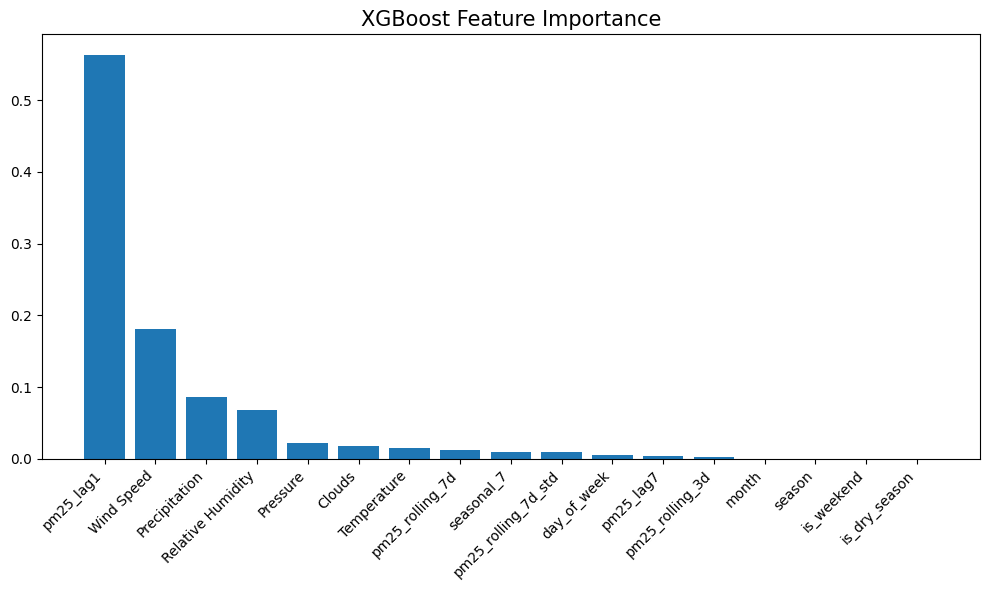

In [39]:
feat_imp = model_xgboost.named_steps['model'].feature_importances_
sorted_idx = np.argsort(feat_imp)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), feat_imp[sorted_idx])
plt.xticks(range(len(features)), [features[i] for i in sorted_idx], rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

pm25_lag1 được sử dụng nhiều và giúp mô hình giảm nhiều sai số nhất (nhưng không biết có quan hệ phi tuyến hay tuyến tính với biến dự đoán hay không)

## LSTM

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import time

2026-05-05 03:39:05.700339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777952345.929499      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777952345.992832      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777952346.531986      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777952346.532030      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777952346.532034      57 computation_placer.cc:177] computation placer alr

In [41]:
# Set seed thư viện tf
tf.random.set_seed(42)

# Hàm tạo các chuỗi dữ liệu cho LSTM
def create_sequences(data, target_index, steps):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i: i + steps, :])     # Dữ liệu đầu vào (cửa sổ trượt)
        y.append(data[i + steps, target_index])    # Giá trị PM25 tại t+1
        
    return np.array(X), np.array(y)

# Hàm chuyển dữ liệu về dạng 3D cho LSTM
# ---> ĐIỂM SỬA: Đổi mặc định time_steps=7 (Nhìn lại 7 ngày quá khứ của dữ liệu Daily)
def prepare_data_lstm(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', time_steps=7, use_env=True):
    
    env_features = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity', 'SO2', 'NO2']
    base_features = ['PM25']
    features = (env_features + base_features) if use_env else base_features
    
    # Chia tập dữ liệu dựa trên mốc thời gian động
    train = train_valid[train_valid['Local Time'] < valid_start].copy()
    valid = train_valid[(train_valid['Local Time'] >= valid_start) & (train_valid['Local Time'] < test_start)].copy()

    # Trích xuất numpy array
    train_data = train[features].values
    valid_data = valid[features].values
    test_data = test[features].values
    
    # Chuẩn hóa dữ liệu (Fit scaler chỉ trên tập Train để tránh Data Leakage)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_data)
    valid_scaled = scaler.transform(valid_data)
    test_scaled = scaler.transform(test_data)
    
    # Vị trí cột PM25
    pm25_index = features.index('PM25')
    
    # --- XỬ LÝ CHỐNG MẤT DỮ LIỆU Ở ĐẦU TẬP VALID VÀ TEST ---
    # Mượn time_steps dòng cuối của tập trước nối vào đầu tập sau
    valid_scaled_extended = np.vstack((train_scaled[-time_steps:], valid_scaled))
    test_scaled_extended = np.vstack((valid_scaled[-time_steps:], test_scaled))
    
    # Tạo các chuỗi dữ liệu cho LSTM
    X_train, y_train = create_sequences(train_scaled, pm25_index, time_steps)
    X_valid, y_valid = create_sequences(valid_scaled_extended, pm25_index, time_steps)
    X_test, y_test = create_sequences(test_scaled_extended, pm25_index, time_steps)
    
    print("Đã chuẩn bị xong dữ liệu 3D cho LSTM :>")
    print("Train shape:", X_train.shape, y_train.shape)
    print("Valid shape:", X_valid.shape, y_valid.shape)
    print("Test shape:", X_test.shape, y_test.shape)
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test, scaler, features

In [43]:
# Cách gọi hàm (bạn tự điều chỉnh mốc thời gian và time_steps cho phù hợp)
X_train_seq, y_train_seq, X_valid_seq, y_valid_seq, X_test_seq, y_test_seq, scaler, features_lstm = prepare_data_lstm(
    train_valid=train_valid, 
    test=test, 
    valid_start='2026-03-01', 
    test_start='2026-03-15', 
    time_steps=2,  # Lùi về quá khứ 8 buổi (2 ngày)
    use_env=True
)

print("X train shape:", X_train_seq.shape)

Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (57, 2, 9) (57,)
Valid shape: (14, 2, 9) (14,)
Test shape: (7, 2, 9) (7,)
X train shape: (57, 2, 9)


In [44]:
model_lstm, history = lstm_model(X_train_seq, y_train_seq, X_valid_seq, y_valid_seq)

Epoch 1/100


2026-05-05 03:39:31.092288: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 1.0269 - mae: 0.7916 - val_loss: 0.5612 - val_mae: 0.5885 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9664 - mae: 0.7706 - val_loss: 0.5444 - val_mae: 0.5732 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9190 - mae: 0.7466 - val_loss: 0.5205 - val_mae: 0.5597 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8125 - mae: 0.7142 - val_loss: 0.4964 - val_mae: 0.5498 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7710 - mae: 0.6945 - val_loss: 0.4765 - val_mae: 0.5410 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6729 - mae: 0.6460 - val_loss: 0.4635 - val_mae: 0.5332 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5890 - mae: 0.6090 - val_loss: 0.4600 - val_mae: 0.5385 - learning_rate: 0.0010
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━

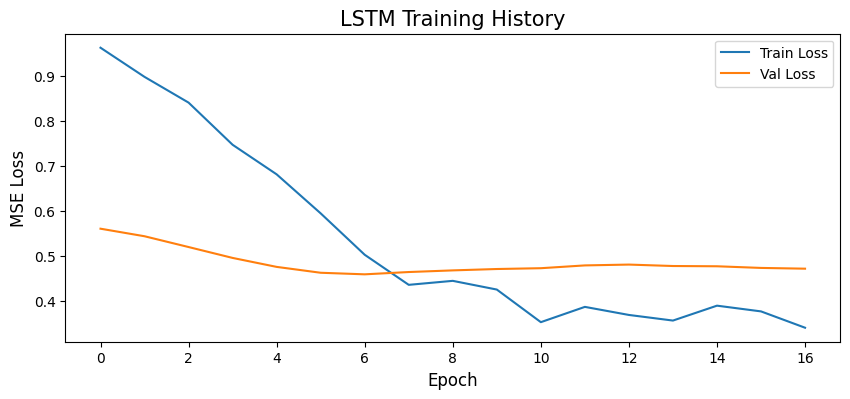

In [45]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

Dùng ReduceLR nên đã giảm được tình trạng overfitting ban đầu :< 

In [46]:
# Đánh giá mô hình lstm
y_valid_pred_scaled_lstm = model_lstm.predict(X_valid_seq)

y_valid, y_pred_lstm = evaluate_model(
    y_true=y_valid_seq, 
    y_pred=y_valid_pred_scaled_lstm, 
    model_name="LSTM",
    scaler=scaler,  
    n_features=X_train_seq.shape[2],
    target_idx=features_lstm.index('PM25')
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step

========== KẾT QUẢ: LSTM ==========
MAE:  13.5298
MSE:  284.2226
RMSE: 16.8589
R2:   0.2133


# Thực nghiệm

## Test

In [49]:
from tensorflow.keras.optimizers import Adam

In [50]:
# from tensorflow.keras.optimizers import Adam
# from xgboost import XGBRegressor
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Gộp train - valid
def xgboost_pipeline_final(X_train, y_train, best_n_estimators=74):

    print(f"Đang huấn luyện XGBoost với {best_n_estimators} cây cố định...")
    
    # Khởi tạo mô hình 
    model = XGBRegressor(
        n_estimators=best_n_estimators,
        learning_rate=0.05, 
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    
    # Chỉ fit trên tập Train (lúc này là tập gộp Train + Valid)
    model.fit(X_train, y_train)
    
    return model


# Không có early stopping, LR cố định
def lstm_model_final(X_train, y_train, best_epochs=20):
    print(f"Đang huấn luyện LSTM với {best_epochs} epochs cố định...")
    
    n_time_steps = X_train.shape[1]
    n_features = X_train.shape[2]
    
    model = Sequential([
        Input(shape=(n_time_steps, n_features)),
        
        # Lớp 1: Quét qua chuỗi dữ liệu quá khứ để học quy luật ngắn hạn
        LSTM(64, return_sequences=True, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),     # thêm L2 chống overfitting
        Dropout(0.4),     # Tránh overfitting
        
        # Lớp 2: Nén các đặc trưng cốt lõi 
        LSTM(32, return_sequences=False, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.4),
        
        # Đầu ra dự báo 
        Dense(16, activation='relu'),
        Dense(1)  # Dự đoán PM2.5
    ])
    
    # Sử dụng Learning Rate cố định đã tối ưu
    optimizer = Adam(learning_rate=2.5e-4) 
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    # Fit mô hình không có Valid
    history = model.fit(
        X_train, y_train,
        epochs=best_epochs,  
        batch_size=8,        # <-- SỬA: Hạ xuống 8 do dữ liệu Daily rất ít dòng (dù đã gộp Train + Valid)
        verbose=1            
    )
    
    return model, history

In [51]:
results_test = {}

# XGBOOST TRÊN TẬP TRAIN_FINAL 
for use_env in [True, False]:
    label = "XGBoost_env_Final" if use_env else "XGBoost_no_env_Final"
    
    t_start = time.time()
    
    
    # Lấy dữ liệu (Chỉ lấy X_tr_final, y_tr_final và X_te, y_te)
    X_tr_final, y_tr_final, _, _, X_te, y_te, features = prepare_data(train_valid, test, use_env=use_env)
    
    # Huấn luyện trên tập gộp. 
    model_xgb = xgboost_pipeline_final(X_tr_final, y_tr_final, best_n_estimators=74)
    t_elapsed = time.time() - t_start
    
    # Đánh giá trên tập Test
    y_pred = model_xgb.predict(X_te)
    _, y_pred_real = evaluate_model(y_te, y_pred, model_name=label)
    
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây\n")
    
    results_test[label] = {
        'model': model_xgb,
        'time': t_elapsed,
        'y_test': y_te,
        'y_pred': y_pred_real
    }

# LSTM TRÊN TẬP TRAIN_FINAL 
for use_env in [True, False]:
    label = "LSTM_env_Final" if use_env else "LSTM_no_env_Final"
    
    t_start = time.time()
    
    # Lấy dữ liệu
    X_tr_final, y_tr_final, _, _, X_te, y_te, scaler, features_lstm = prepare_data_lstm(train_valid, test, use_env=use_env)
    
    # Huấn luyện trên tập gộp. 
    model_lstm, history = lstm_model_final(X_tr_final, y_tr_final, best_epochs=20) 
    t_elapsed = time.time() - t_start
    
    # Đánh giá trên tập Test
    y_pred = model_lstm.predict(X_te)
    y_true_real, y_pred_real = evaluate_model(y_te, y_pred, model_name=label,
                                    scaler=scaler,
                                    n_features=len(features_lstm),
                                    target_idx=features_lstm.index('PM25'))
    
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây\n")
    
    results_test[label] = {
        'model': model_lstm,
        'scaler': scaler,
        'time': t_elapsed,
        'history': history,
        'y_test': y_true_real,
        'y_pred': y_pred_real
    }

Đã chuẩn bị xong dữ liệu :>
Train shape: (52, 17) (52,)
Valid shape: (24, 17) (24,)
Test shape: (7, 17) (7,)
Đang huấn luyện XGBoost với 74 cây cố định...

========== KẾT QUẢ: XGBOOST_ENV_FINAL ==========
MAE:  9.1933
MSE:  100.7856
RMSE: 10.0392
R2:   0.2422
Tổng thời gian (XGBoost_env_Final): 0.06 giây

Đã chuẩn bị xong dữ liệu :>
Train shape: (52, 11) (52,)
Valid shape: (24, 11) (24,)
Test shape: (7, 11) (7,)
Đang huấn luyện XGBoost với 74 cây cố định...

========== KẾT QUẢ: XGBOOST_NO_ENV_FINAL ==========
MAE:  7.1437
MSE:  84.1604
RMSE: 9.1739
R2:   0.3672
Tổng thời gian (XGBoost_no_env_Final): 0.06 giây

Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (52, 7, 9) (52,)
Valid shape: (24, 7, 9) (24,)
Test shape: (7, 7, 9) (7,)
Đang huấn luyện LSTM với 20 epochs cố định...
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7863 - mae: 0.7379
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7659 - mae: 0.7319 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss

In [52]:
# Bảng tổng kết
print("\n" + "="*60)
print("TỔNG KẾT CÁC THỰC NGHIỆM")
print("="*60)
print(f"{'Mô hình':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'Time(s)':>10}")
print("-"*60)
for label, res in results_test.items():
    mae  = mean_absolute_error(res['y_test'], res['y_pred'])
    rmse = np.sqrt(mean_squared_error(res['y_test'], res['y_pred']))
    r2   = r2_score(res['y_test'], res['y_pred'])
    print(f"{label:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {res['time']:>10.2f}")
print("="*60)


TỔNG KẾT CÁC THỰC NGHIỆM
Mô hình                        MAE     RMSE       R2    Time(s)
------------------------------------------------------------
XGBoost_env_Final           9.1933  10.0392   0.2422       0.06
XGBoost_no_env_Final        7.1437   9.1739   0.3672       0.06
LSTM_env_Final             10.5796  12.2922  -0.1362       5.05
LSTM_no_env_Final          11.9516  14.7416  -0.6341       5.04


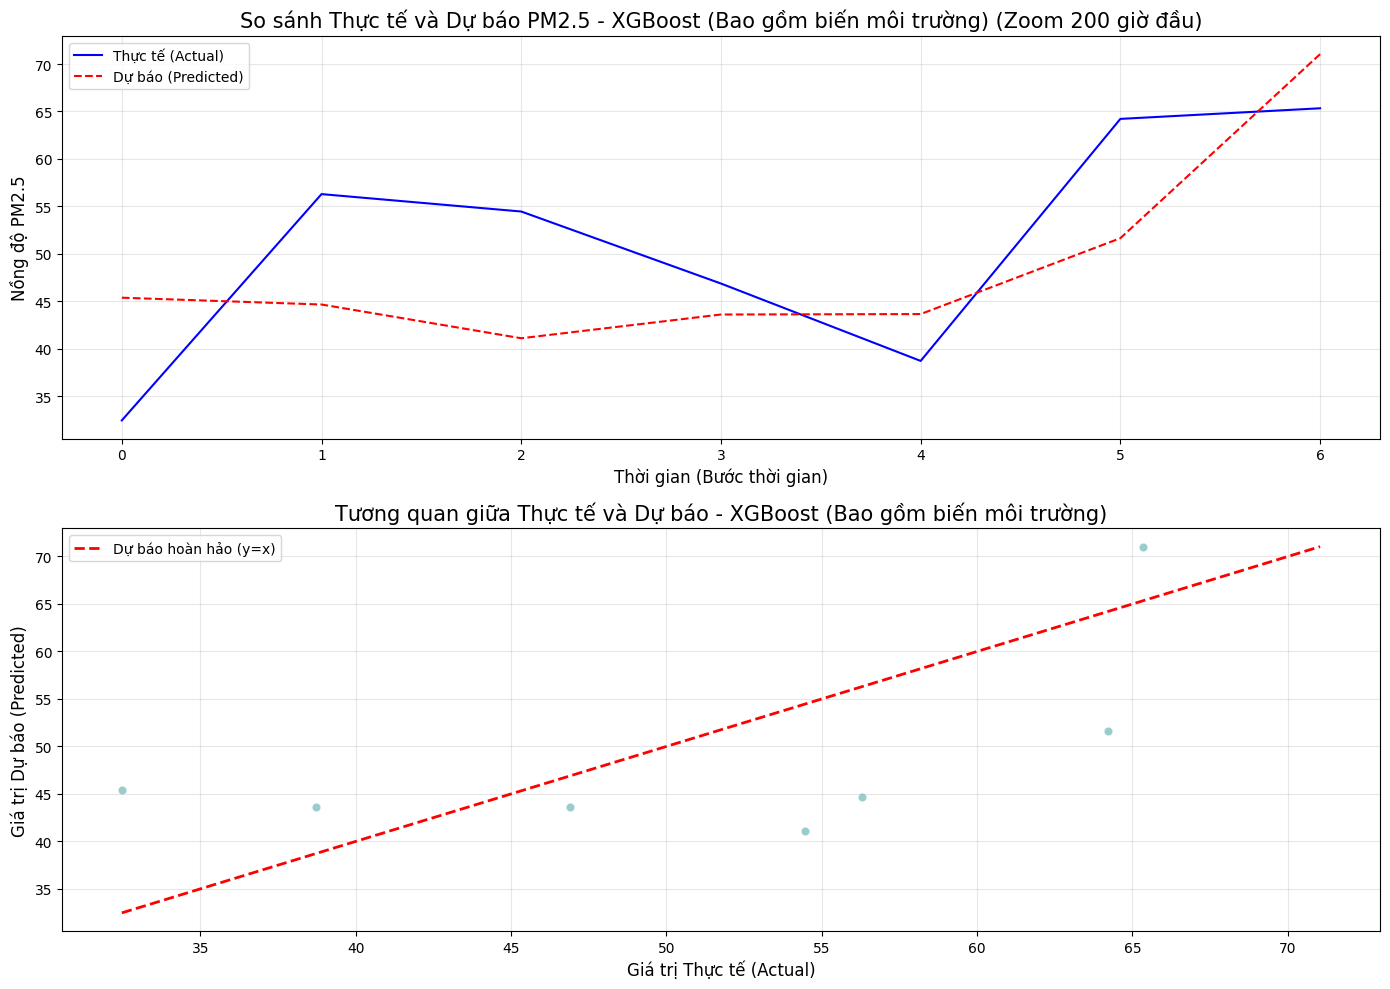

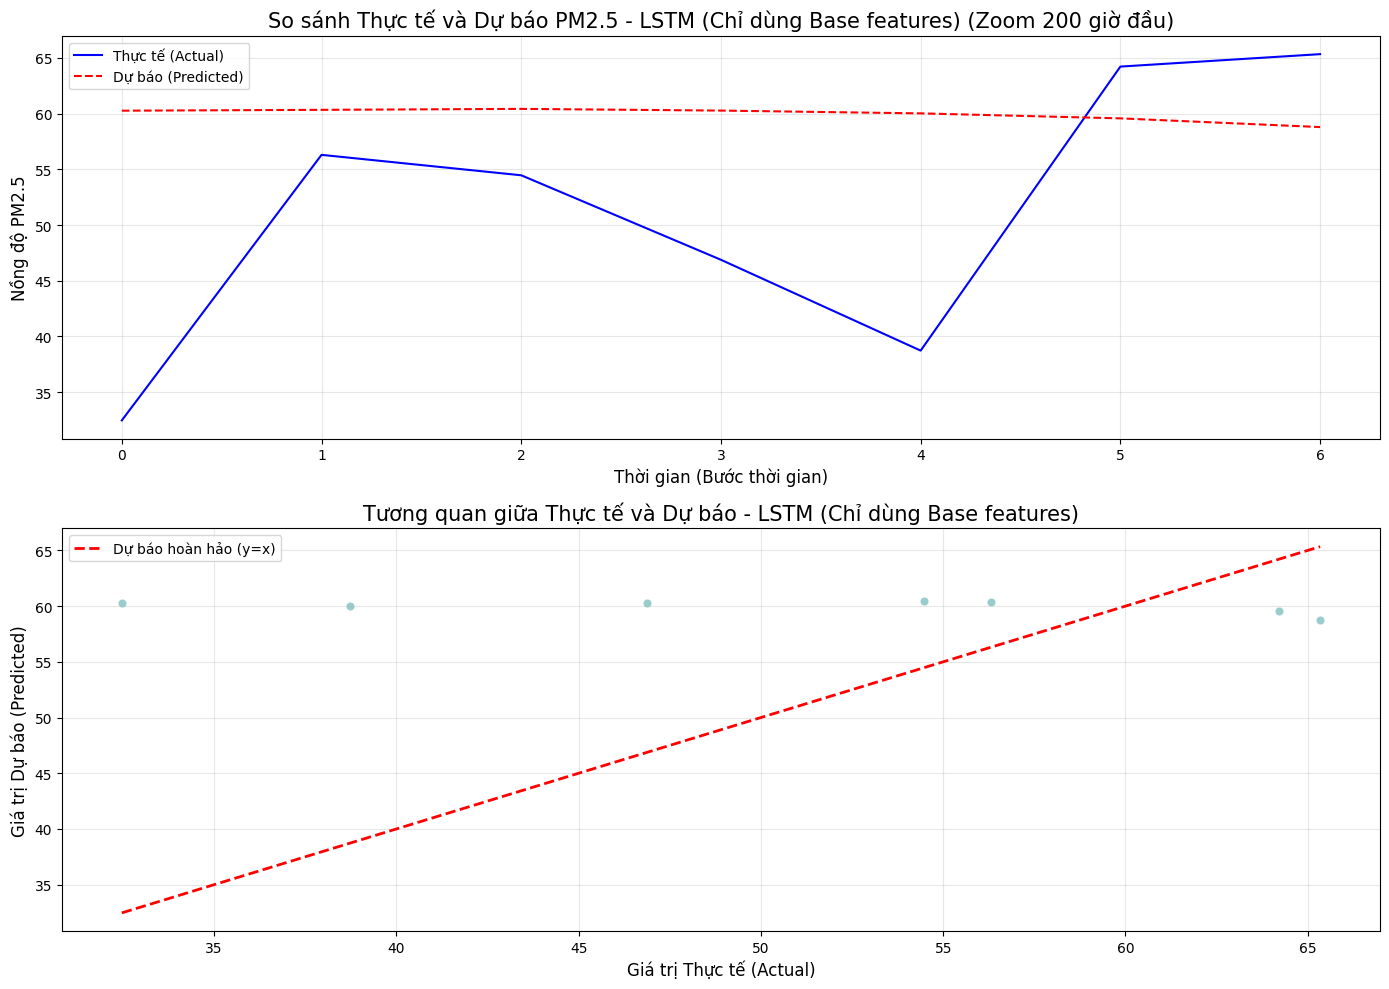

In [53]:
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Mô hình", num_points=200):
    """
    Hàm vẽ đồ thị so sánh giá trị thực tế và dự báo PM2.5.
    y_true: mảng giá trị thực tế.
    y_pred: mảng giá trị dự báo.
    num_points: số lượng điểm dữ liệu cắt ra để vẽ biểu đồ đường (giúp dễ quan sát hơn).
    """
    # Đảm bảo dữ liệu ở dạng mảng 1 chiều
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    plt.figure(figsize=(14, 10))

    # --- 1. Biểu đồ đường (Line Plot) theo thời gian ---
    plt.subplot(2, 1, 1)
    # Lấy num_points điểm đầu tiên (hoặc có thể đổi thành khoảng thời gian bạn muốn)
    plt.plot(y_true[:num_points], label='Thực tế (Actual)', color='blue', linewidth=1.5)
    plt.plot(y_pred[:num_points], label='Dự báo (Predicted)', color='red', linestyle='--', linewidth=1.5)
    
    plt.title(f'So sánh Thực tế và Dự báo PM2.5 - {model_name} (Zoom {num_points} giờ đầu)')
    plt.xlabel('Thời gian (Bước thời gian)')
    plt.ylabel('Nồng độ PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- 2. Biểu đồ phân tán (Scatter Plot) tương quan ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color='teal')
    
    # Vẽ đường chéo y = x (hoàn hảo)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Dự báo hoàn hảo (y=x)')

    plt.title(f'Tương quan giữa Thực tế và Dự báo - {model_name}')
    plt.xlabel('Giá trị Thực tế (Actual)')
    plt.ylabel('Giá trị Dự báo (Predicted)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH GỌI HÀM VỚI DỮ LIỆU CỦA BẠN
# ==========================================
# Dựa vào dictionary `results_test` bạn đã lưu ở bước đánh giá trước đó:

# Vẽ cho mô hình XGBoost (có biến môi trường)
y_test_xgb = results_test['XGBoost_env_Final']['y_test']
y_pred_xgb = results_test['XGBoost_env_Final']['y_pred']
plot_actual_vs_predicted(y_test_xgb, y_pred_xgb, model_name="XGBoost (Bao gồm biến môi trường)", num_points=200)

#Vẽ cho mô hình LSTM (không có biến môi trường)
y_test_lstm = results_test['LSTM_no_env_Final']['y_test']
y_pred_lstm = results_test['LSTM_no_env_Final']['y_pred']
plot_actual_vs_predicted(y_test_lstm, y_pred_lstm, model_name="LSTM (Chỉ dùng Base features)", num_points=200)

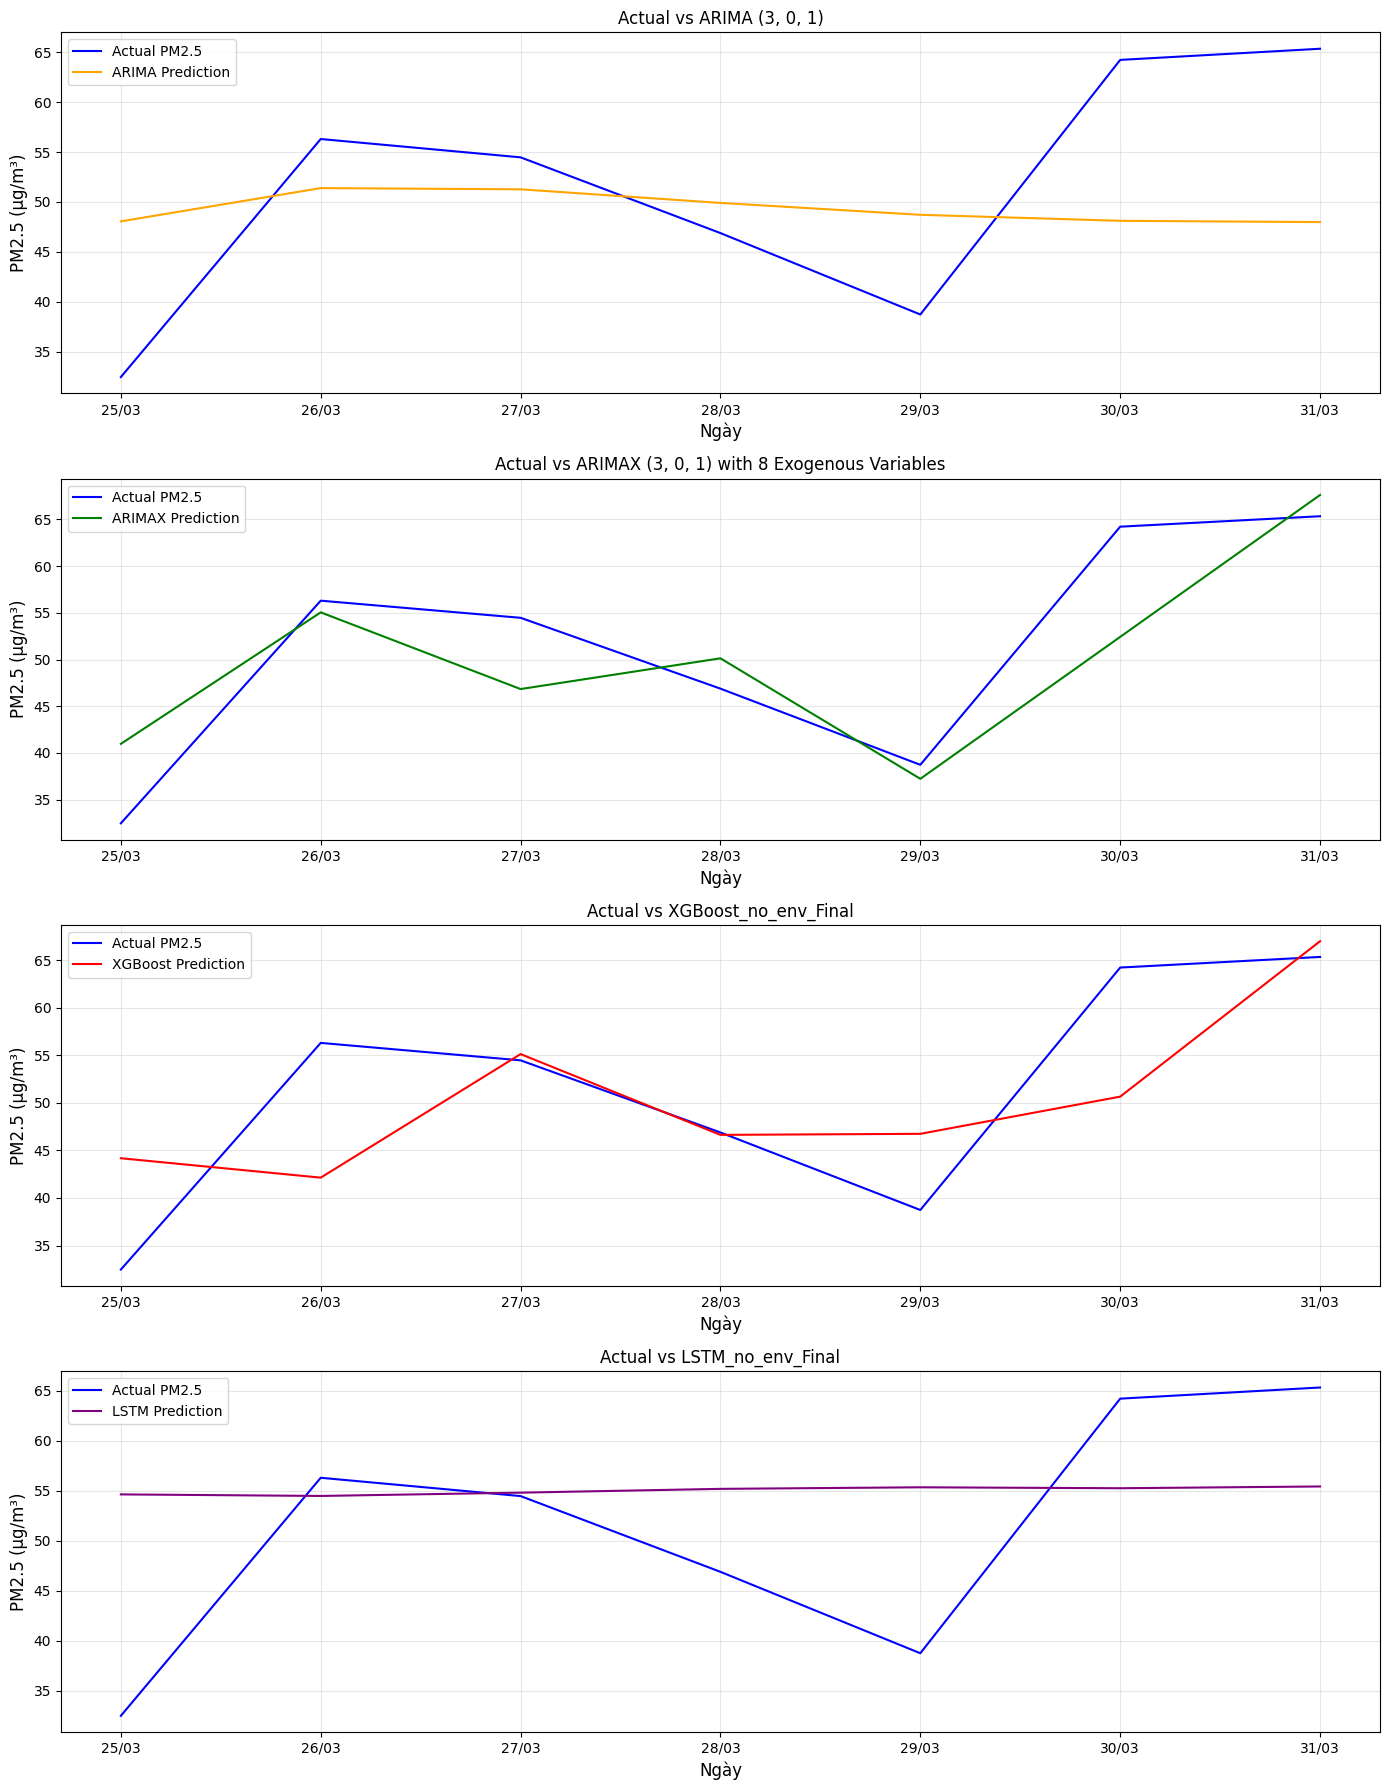

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# BƯỚC 1: TRÍCH XUẤT VÀ ÉP KIỂU DỮ LIỆU (CHỐNG LỖI MATPLOTLIB)
# ==============================================================================
# Trích xuất trục thời gian trực tiếp từ cột 'Local Time' (ép về datetime)
time_index = pd.to_datetime(test['Local Time'])

# 1. Dữ liệu ARIMA (Trỏ đích danh vào cột PM25 thay vì lấy toàn bộ bảng)
y_actual_arima = np.asarray(test['PM25'].values, dtype=float).flatten()
y_pred_arima = np.asarray(forecast.values, dtype=float).flatten()

# 2. Dữ liệu ARIMAX 
y_actual_arimax = np.asarray(endog_test_raw.values, dtype=float).flatten()
y_pred_arimax = np.asarray(forecast_arimax.values, dtype=float).flatten()

# 3. Dữ liệu XGBoost (Không môi trường)
y_actual_xgb = np.asarray(results_test['XGBoost_no_env_Final']['y_test'], dtype=float).flatten()
y_pred_xgb = np.asarray(results_test['XGBoost_no_env_Final']['y_pred'], dtype=float).flatten()

# 4. Dữ liệu LSTM (Có môi trường)
y_actual_lstm = np.asarray(results_test['LSTM_no_env_Final']['y_test'], dtype=float).flatten()
y_pred_lstm = np.asarray(results_test['LSTM_no_env_Final']['y_pred'], dtype=float).flatten()

# ==============================================================================
# BƯỚC 2: KHỞI TẠO FIGURE VÀ 4 SUBPLOTS THEO CHIỀU DỌC
# ==============================================================================
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 18))

# ==============================================================================
# BƯỚC 3: VẼ TỪNG ĐỒ THỊ
# ==============================================================================

# --- ĐỒ THỊ 1: ARIMA ---
axes[0].plot(time_index, y_actual_arima, color='blue', label='Actual PM2.5')
axes[0].plot(time_index, y_pred_arima, color='orange', label='ARIMA Prediction')
axes[0].set_title(f"Actual vs ARIMA {selected_order}", fontsize=12)
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xlabel('Ngày')
axes[0].legend(loc='upper left')

# --- ĐỒ THỊ 2: ARIMAX ---
axes[1].plot(time_index, y_actual_arimax, color='blue', label='Actual PM2.5')
axes[1].plot(time_index, y_pred_arimax, color='green', label='ARIMAX Prediction')
axes[1].set_title("Actual vs ARIMAX (3, 0, 1) with 8 Exogenous Variables", fontsize=12)
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_xlabel('Ngày')
axes[1].legend(loc='upper left')

# --- ĐỒ THỊ 3: XGBoost ---
axes[2].plot(time_index, y_actual_xgb, color='blue', label='Actual PM2.5')
axes[2].plot(time_index, y_pred_xgb, color='red', label='XGBoost Prediction')
axes[2].set_title("Actual vs XGBoost_no_env_Final", fontsize=12)
axes[2].set_ylabel('PM2.5 (µg/m³)')
axes[2].set_xlabel('Ngày')
axes[2].legend(loc='upper left')

# --- ĐỒ THỊ 4: LSTM ---
axes[3].plot(time_index, y_actual_lstm, color='blue', label='Actual PM2.5')
axes[3].plot(time_index, y_pred_lstm, color='purple', label='LSTM Prediction') 
axes[3].set_title("Actual vs LSTM_no_env_Final", fontsize=12)
axes[3].set_ylabel('PM2.5 (µg/m³)')
axes[3].set_xlabel('Ngày')
axes[3].legend(loc='upper left')

# ==============================================================================
# BƯỚC 4: TINH CHỈNH VÀ HIỂN THỊ TRỰC QUAN
# ==============================================================================
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()